In [2]:
%load_ext autoreload
%autoreload 2

from scripts.lattice import *
from scripts.scba import *
from scripts.plot import *
from scripts.obs import *
from scripts.utils import *
from triqs.gf import *

import seaborn as sns
color_list = sns.color_palette('colorblind') + sns.color_palette("Set2") + sns.color_palette("Set3")

def update_mpl_params(bigger_labels=0):
    mpl.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.size": 16+bigger_labels,
        "axes.labelsize": 18+bigger_labels,
        "axes.titlesize": 18+bigger_labels,
        "xtick.labelsize": 16+bigger_labels,
        "ytick.labelsize": 16+bigger_labels,
        "legend.fontsize": 14+bigger_labels//2,
        "figure.titlesize": 20+3*bigger_labels//2,
    })
    
dim = 3
save_dir = f'data/{dim}d/rpa_ba'

Starting serial run at: 2026-09-09 23:38:50.773357


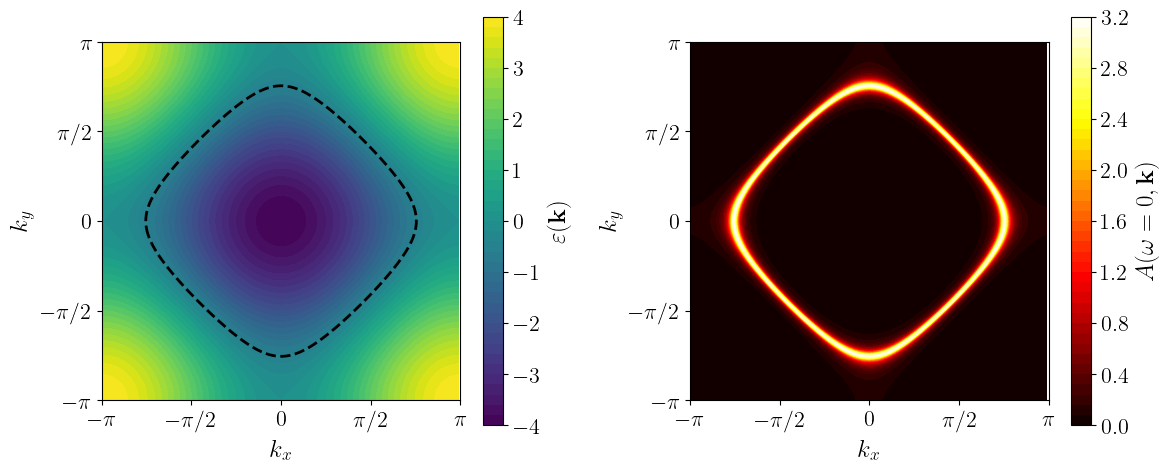

In [60]:
lat = LATTICE(dim=2)
nk = 200

bz = BZ(lat, nk=nk, ibz=False)

kx = bz.k_vecs[:,0].reshape(nk,nk)
ky = bz.k_vecs[:,1].reshape(nk,nk)
e_k = bz.e_k.reshape(nk,nk)

kx -= np.pi
ky -= np.pi
e_k = np.roll(np.roll(e_k, nk//2, axis=0), nk//2, axis=1)

Gamma = 0.1
mu = get_mu(e_k=bz.e_k, n_goal=0.75, beta=1/0.01)
A_k0 = (1/np.pi) * Gamma / (Gamma**2 + (e_k - mu)**2)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

cf = axs[0].contourf(kx, ky, e_k, levels=50)
plt.colorbar(cf, ax=axs[0], label=r'$\varepsilon(\mathbf{k})$')
axs[0].contour(kx, ky, e_k, levels=[mu], colors='black', linewidths=2)

cf = axs[1].contourf(kx, ky, A_k0, levels=50, cmap='hot')
plt.colorbar(cf, ax=axs[1], label=r'$A(\omega=0, \mathbf{k})$')

for ax in axs:
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

/tmp/ipykernel_342215/3386969590.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


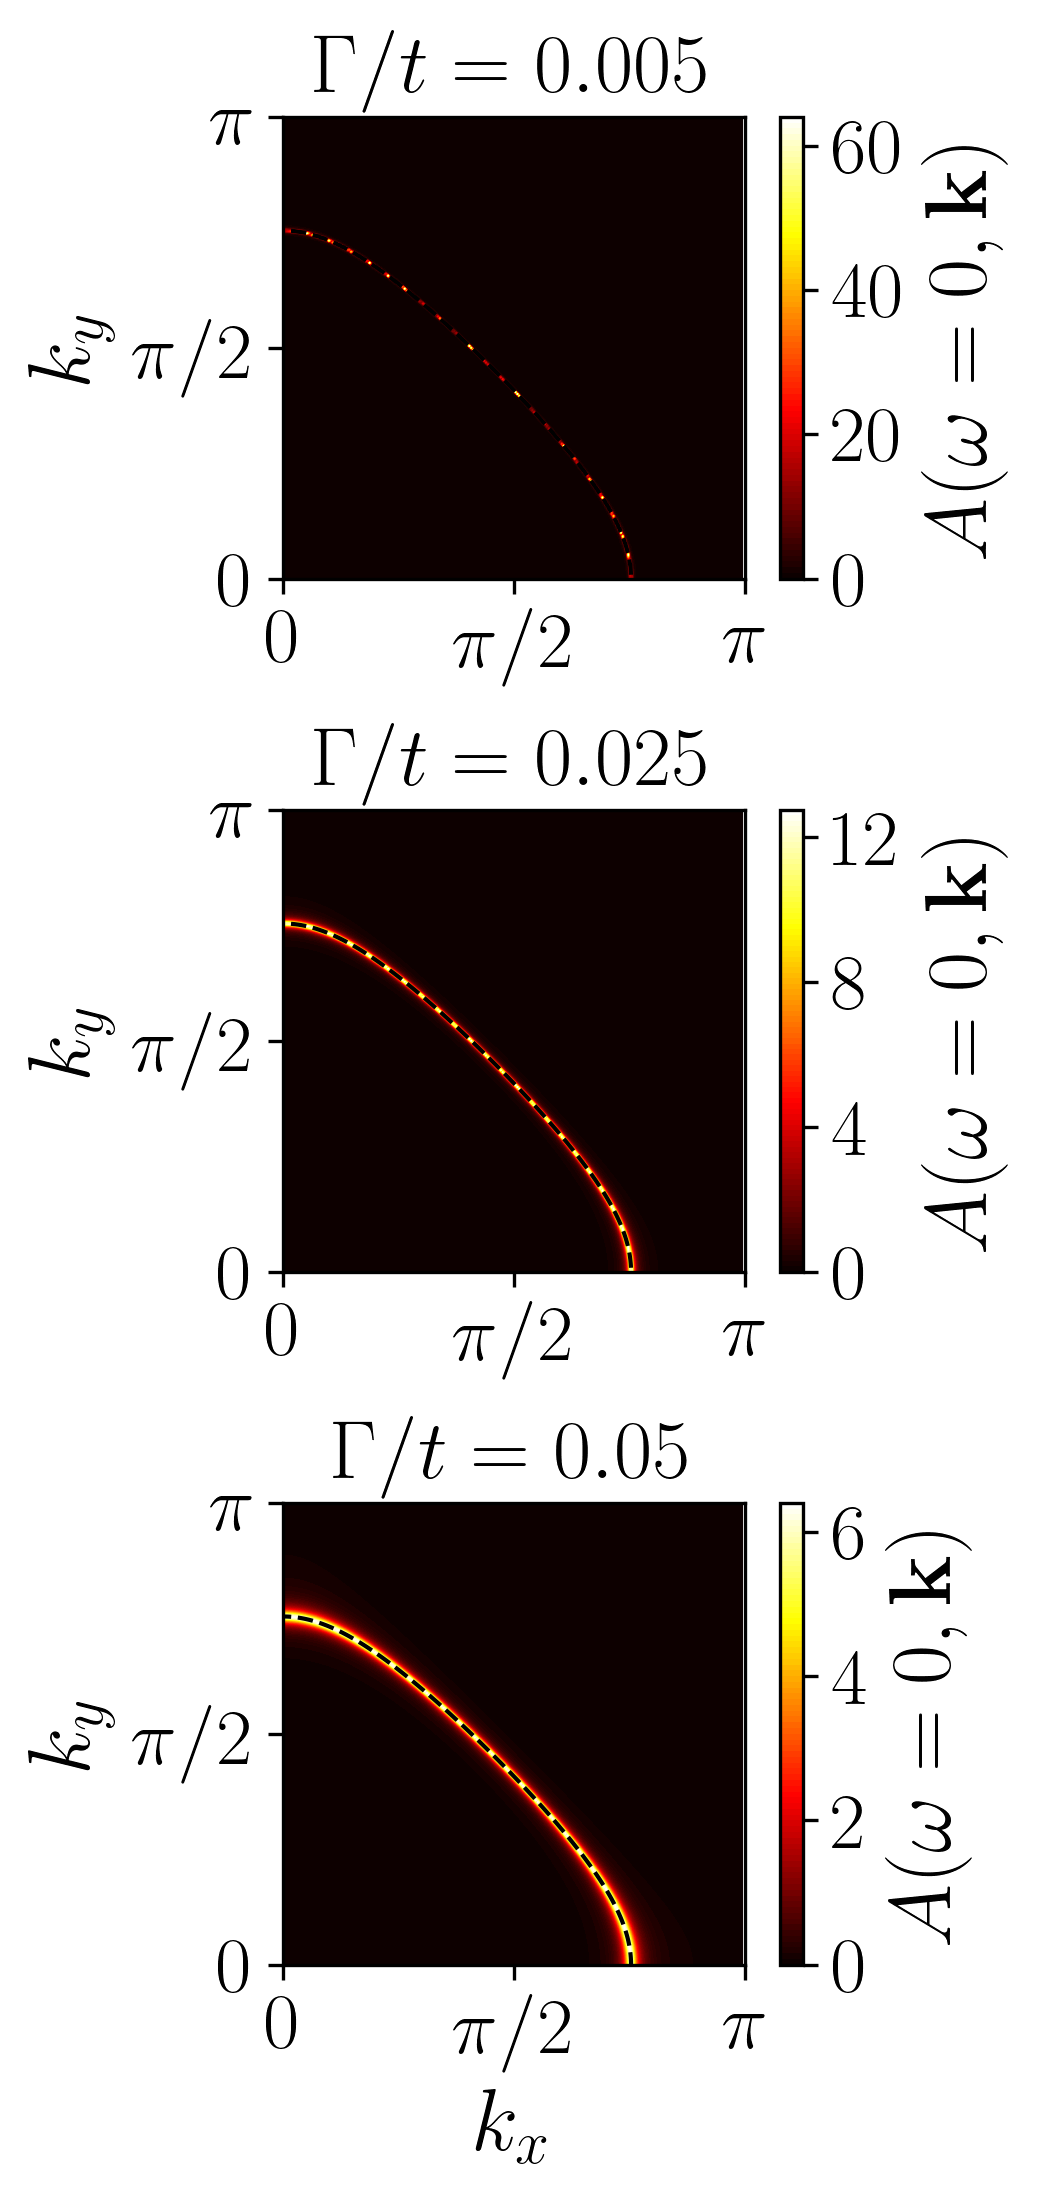

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

update_mpl_params(bigger_labels=3)

fig, axs = plt.subplots(3, 1, figsize=(3, 8), gridspec_kw={'hspace': 0.5})

Gamma_list = [0.005, 0.025, 0.05]
for i, Gamma in enumerate(Gamma_list):

    lat = LATTICE(dim=2)
    nk = 500

    bz = BZ(lat, nk=nk, ibz=False)

    kx = bz.k_vecs[:,0].reshape(nk,nk)
    ky = bz.k_vecs[:,1].reshape(nk,nk)
    e_k = bz.e_k.reshape(nk,nk)

    kx -= np.pi
    ky -= np.pi
    e_k = np.roll(np.roll(e_k, nk//2, axis=0), nk//2, axis=1)

    T = 0.01
    mu = get_mu(e_k=bz.e_k, n_goal=0.75, beta=1/0.01)
    A_k0 = (1/np.pi) * Gamma / (Gamma**2 + (e_k - mu)**2)

    cf = axs[i].contourf(kx, ky, A_k0, levels=100, cmap='hot')
    
    # Automatically selects nice round ticks without altering numerical values
    plt.colorbar(cf, ax=axs[i], label=r'$A(\omega=0, \mathbf{k})$', ticks=MaxNLocator(nbins=4))

    axs[i].contour(kx, ky, e_k, levels=[mu], colors='black', linewidths=1)

    axs[i].set_title(rf"$\Gamma/t = {Gamma}$", size=5*mpl.rcParams['figure.titlesize']//6)

    axs[i].set_xticks([-np.pi, 0, np.pi], labels=[r'$-\pi$', '0', r'$\pi$'])
    axs[i].set_aspect('equal')
    axs[i].set_yticks([-np.pi, 0, np.pi], labels=[r'$-\pi$', '0', r'$\pi$'])
    axs[i].set_ylabel(r'$k_y$')

    axs[i].set_xticks([0, np.pi/2, np.pi], labels=['0', r'$\pi/2$', r'$\pi$'])
    axs[i].set_yticks([0, np.pi/2, np.pi], labels=['0', r'$\pi/2$', r'$\pi$'])
    axs[i].set_xlim(0, np.pi)
    axs[i].set_ylim(0, np.pi)
    axs[i].set_aspect('equal')

axs[-1].set_xlabel(r'$k_x$')

fig.set_dpi(300)
plt.tight_layout()
plt.show()

v = 0.1, Gamma = 0.005325109440231003
v = 0.25, Gamma = 0.03322336225981746
v = 0.5, Gamma = 0.13118309148186066


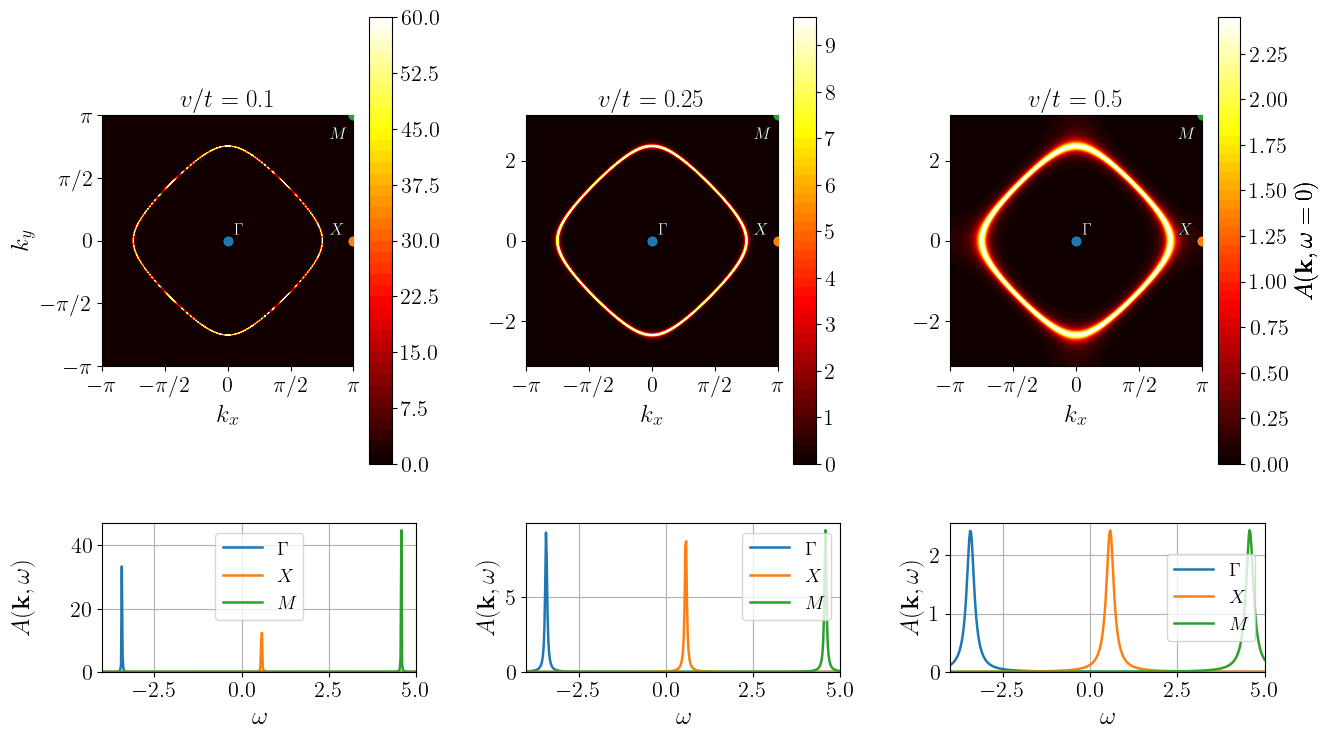

In [130]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

# Height ratios set to [1.2, 0.75] to make the bottom row shorter than the top row
fig, axs = plt.subplots(
    2, 3, 
    figsize=(15, 8.5), 
    gridspec_kw={'wspace': 0.35, 'hspace': 0.2, 'height_ratios': [1.5, 0.5]}
)

v_list = [0.1, 0.25, 0.5]

label_offsets = {
    r'$\Gamma$': (0.15, 0.15),
    r'$X$': (-0.6, 0.15),
    r'$M$': (-0.6, -0.6)
}

for i, v in enumerate(v_list):

    lat = LATTICE(dim=2)
    nk = 500
    niw = 100

    bz = BZ(lat, nk=nk, ibz=False)

    kx = bz.k_vecs[:, 0].reshape(nk, nk) - np.pi
    ky = bz.k_vecs[:, 1].reshape(nk, nk) - np.pi
    e_k = np.roll(np.roll(bz.e_k.reshape(nk, nk), nk // 2, axis=0), nk // 2, axis=1)

    par = {'T': 0.01, 'n': 0.745}

    scba = SCBA(lat, bz, niw)
    result = scba.run(par, v, mix=0.5, verbose=False)

    mu = result['mu']
    S_iw = result['S_iwk'][:, 0]  # Matsubara self-energy

    # Real Frequency Grid
    w = np.linspace(-4, 5, 400)

    S_0 = S_iw[0] 
    print(f"v = {v}, Gamma = {-S_0.imag}")
    
    # Retarded Green's function
    G_ret = 1 / (
        w[:, None, None]
        + mu
        - e_k[None, :, :]
        - S_0  
    )

    # Real-frequency Spectral Function A(k, w)
    A_w = -1 / np.pi * G_ret.imag

    # ---------------- BZ plot at Fermi Level (w ~ 0) ----------------

    iw0 = np.argmin(np.abs(w))
    A_k0 = A_w[iw0]

    cf = axs[0, i].contourf(kx, ky, A_k0, levels=50, cmap='hot')
    plt.colorbar(cf, ax=axs[0, i], label=r'$A(\mathbf{k}, \omega=0)$')

    axs[0, i].set_title(f"$v/t$ = {v}")
    axs[0, i].set_xlabel(r'$k_x$')
    axs[0, i].set_xticks(
        [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
        labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$']
    )
    axs[0, i].set_aspect('equal')

    # Fix BZ plot boundaries
    axs[0, i].set_xlim(-np.pi, np.pi)
    axs[0, i].set_ylim(-np.pi, np.pi)

    # ---------------- High-Symmetry Points & Frequency Plots ----------------

    points = {
        r'$\Gamma$': (0, 0),
        r'$X$': (np.pi, 0),
        r'$M$': (np.pi, np.pi)
    }

    for label, (kx0, ky0) in points.items():
        ix = np.argmin(np.abs(kx[:, 0] - kx0))
        iy = np.argmin(np.abs(ky[0, :] - ky0))

        line, = axs[1, i].plot(
            w,
            A_w[:, iy, ix],
            label=label,
            linewidth=1.8
        )
        color = line.get_color()

        # Scatter point on BZ plot
        axs[0, i].scatter(
            kx0, ky0,
            color=color,
            edgecolor='black',
            linewidth=1.0,
            s=70,
            zorder=5
        )

        # White text labels with 0.6 offsets and subtle stroke
        ox, oy = label_offsets[label]
        txt = axs[0, i].text(
            kx0 + ox, ky0 + oy,
            label,
            color='white',
            fontsize=12,
            fontweight='bold',
            zorder=6
        )
        txt.set_path_effects([path_effects.withStroke(linewidth=1.2, foreground='black')])

    axs[1, i].set_xlabel(r'$\omega$')
    axs[1, i].set_ylabel(r'$A(\mathbf{k},\omega)$')
    axs[1, i].grid()
    axs[1, i].legend()

    # Fix frequency plot bounds
    axs[1, i].set_xlim(-4, 5)
    axs[1, i].set_ylim(bottom=0)

# Labels and ticks for top-left BZ plot
axs[0, 0].set_ylabel(r'$k_y$')
axs[0, 0].set_yticks(
    [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
    labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$']
)

fig.align_labels()
plt.show()

In [5]:
T_list = np.linspace(0.005, 0.2, 21)
print(T_list)

[0.005   0.01475 0.0245  0.03425 0.044   0.05375 0.0635  0.07325 0.083
 0.09275 0.1025  0.11225 0.122   0.13175 0.1415  0.15125 0.161   0.17075
 0.1805  0.19025 0.2    ]


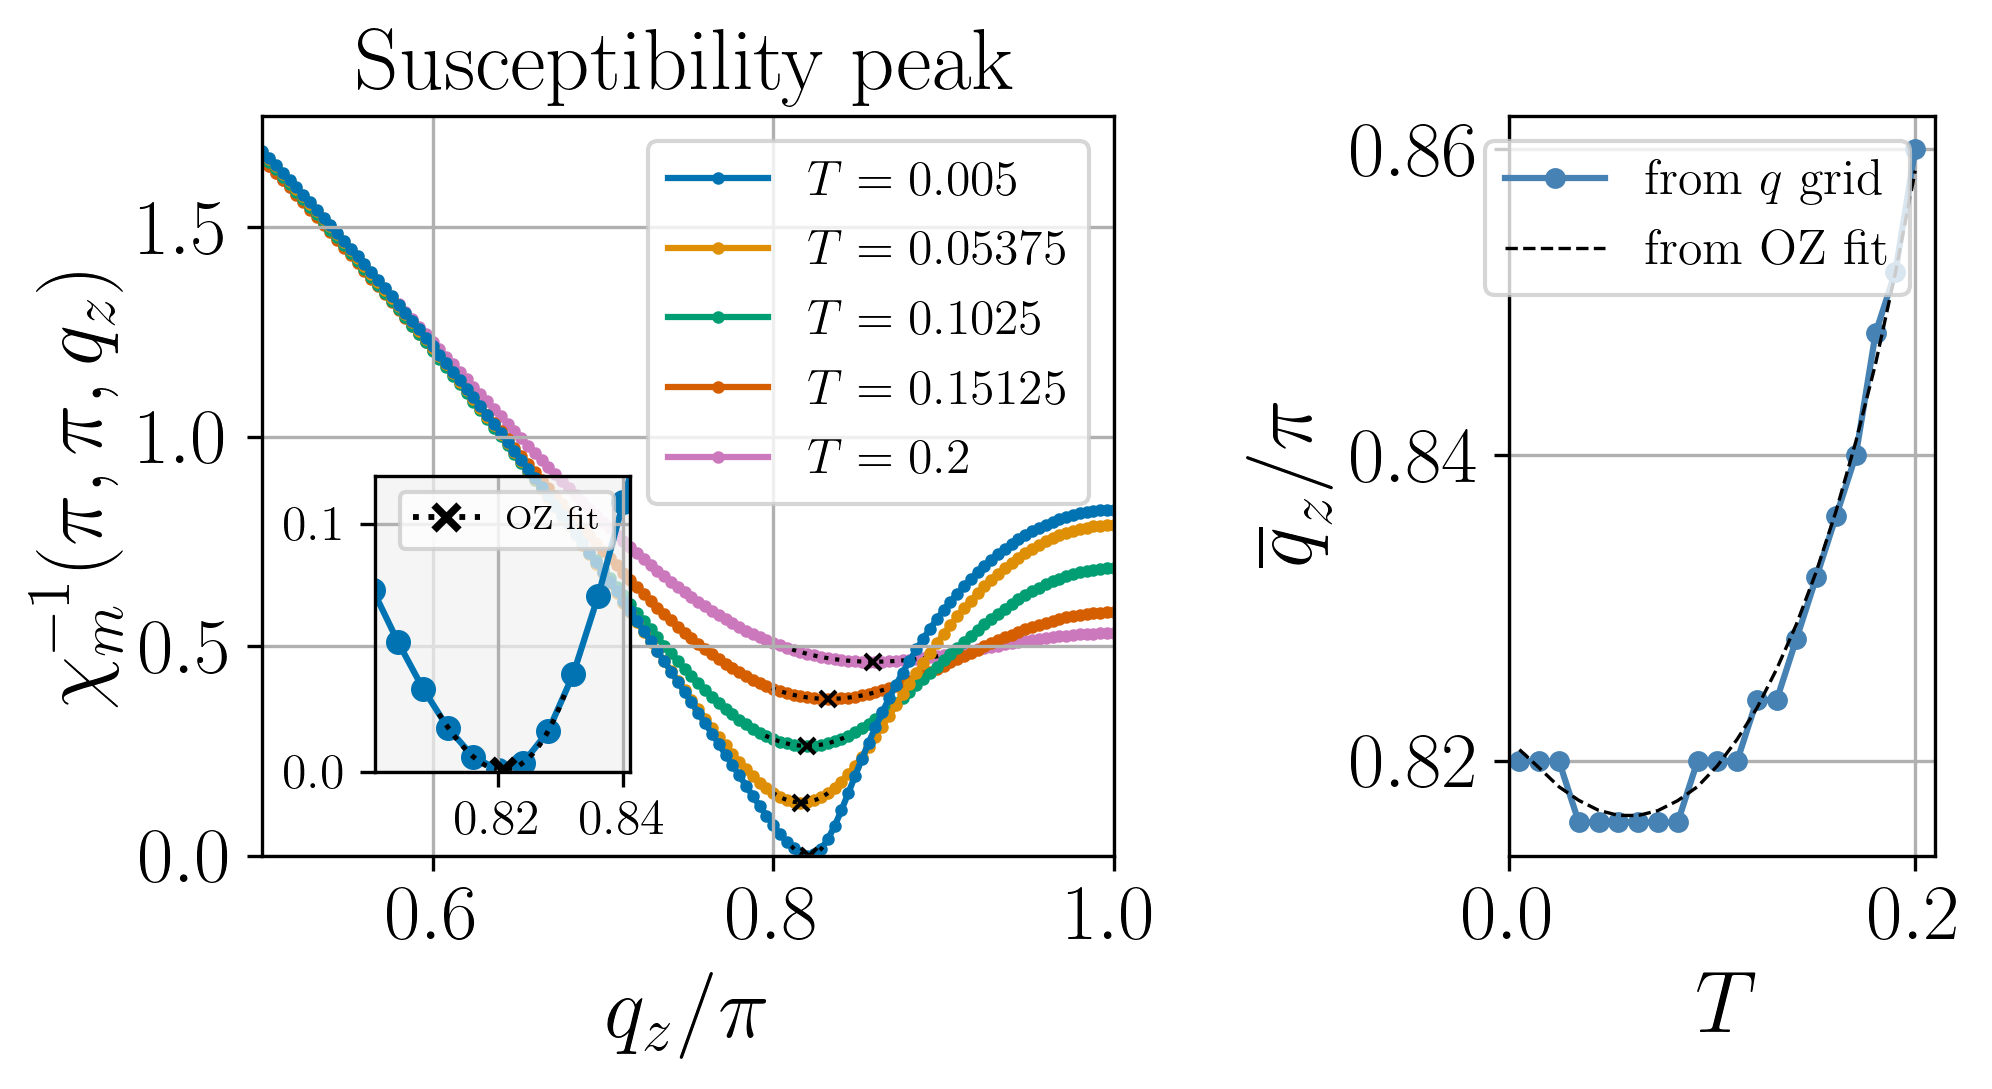

In [12]:
n = 0.851
U = 3

with HDFArchive(f"data/chimin/G0.05tp0n{n:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_chimin(data, peak_on_the='right', figsize=(7, 4), bigger_labels=3, plot_every=5)
plt.show()

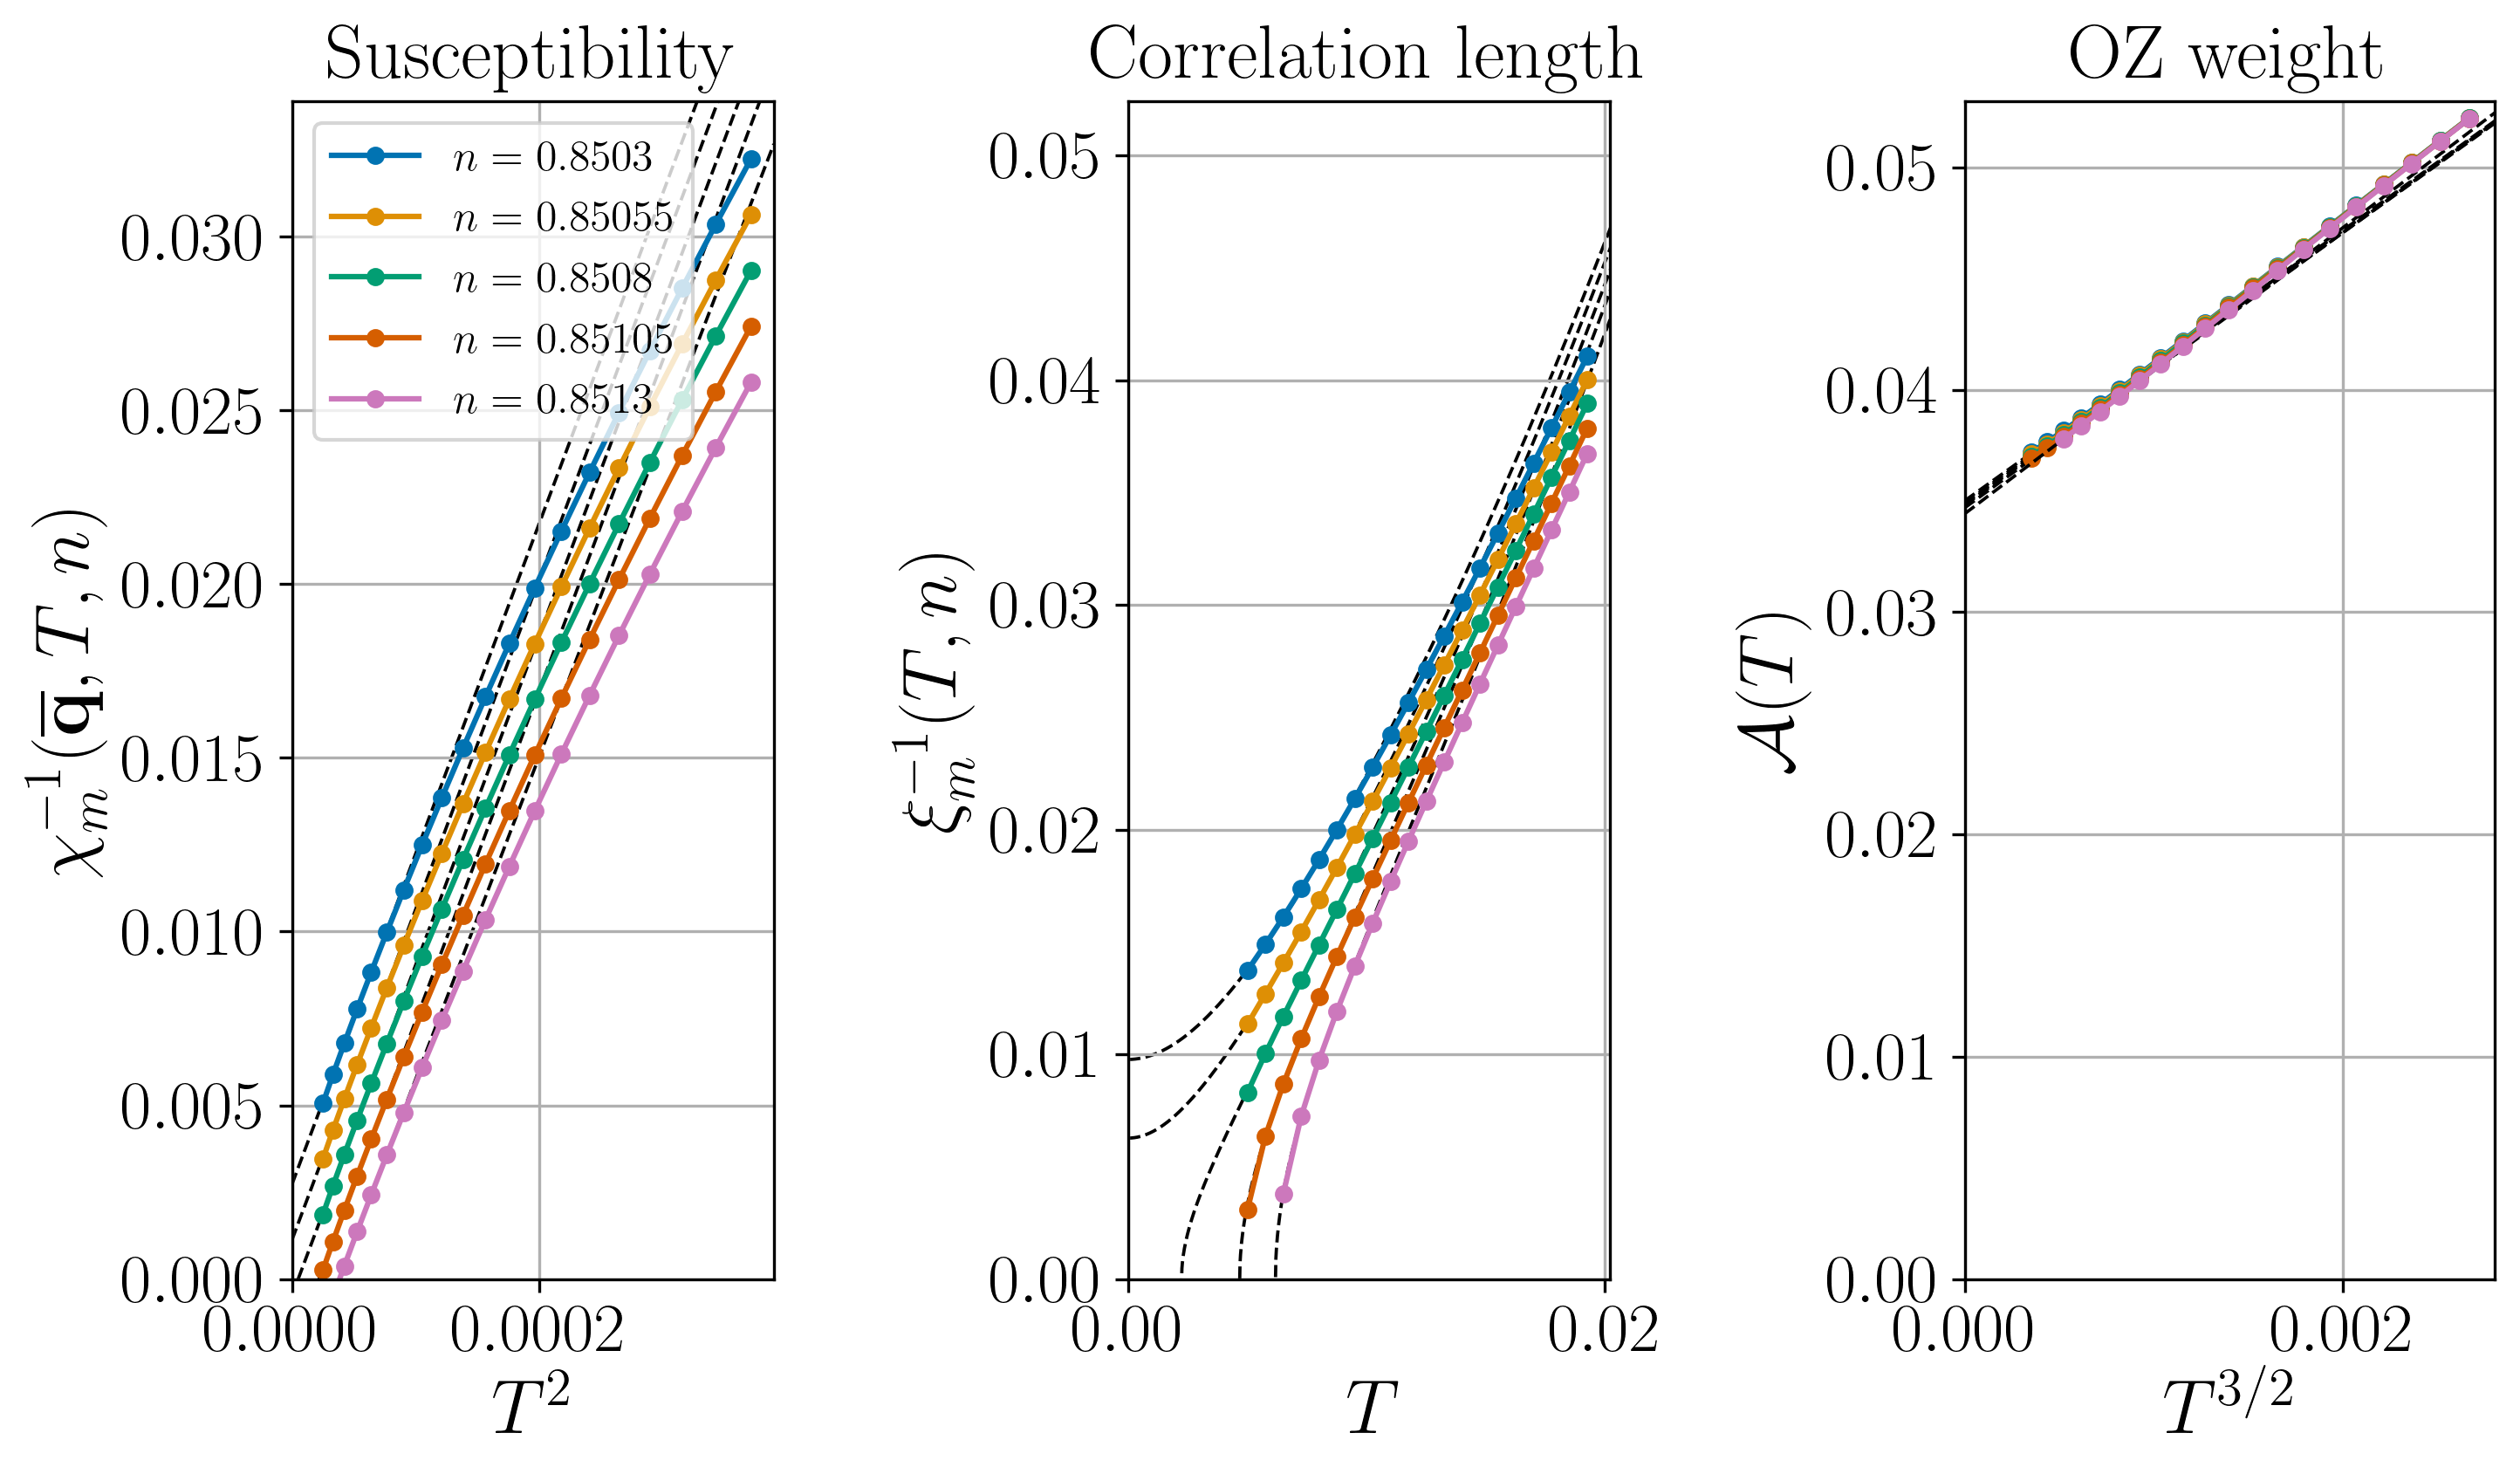

In [20]:
U = 3
Gamma = 0.05

data = {}
with HDFArchive(f"data/scaling/G{Gamma:.5g}tp0U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(2, 1, 1.5), fit=True, right='OZ', figsize=(10, 6), bigger_labels=3)
plt.show()

/tmp/ipykernel_453563/2851939553.py:80: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(


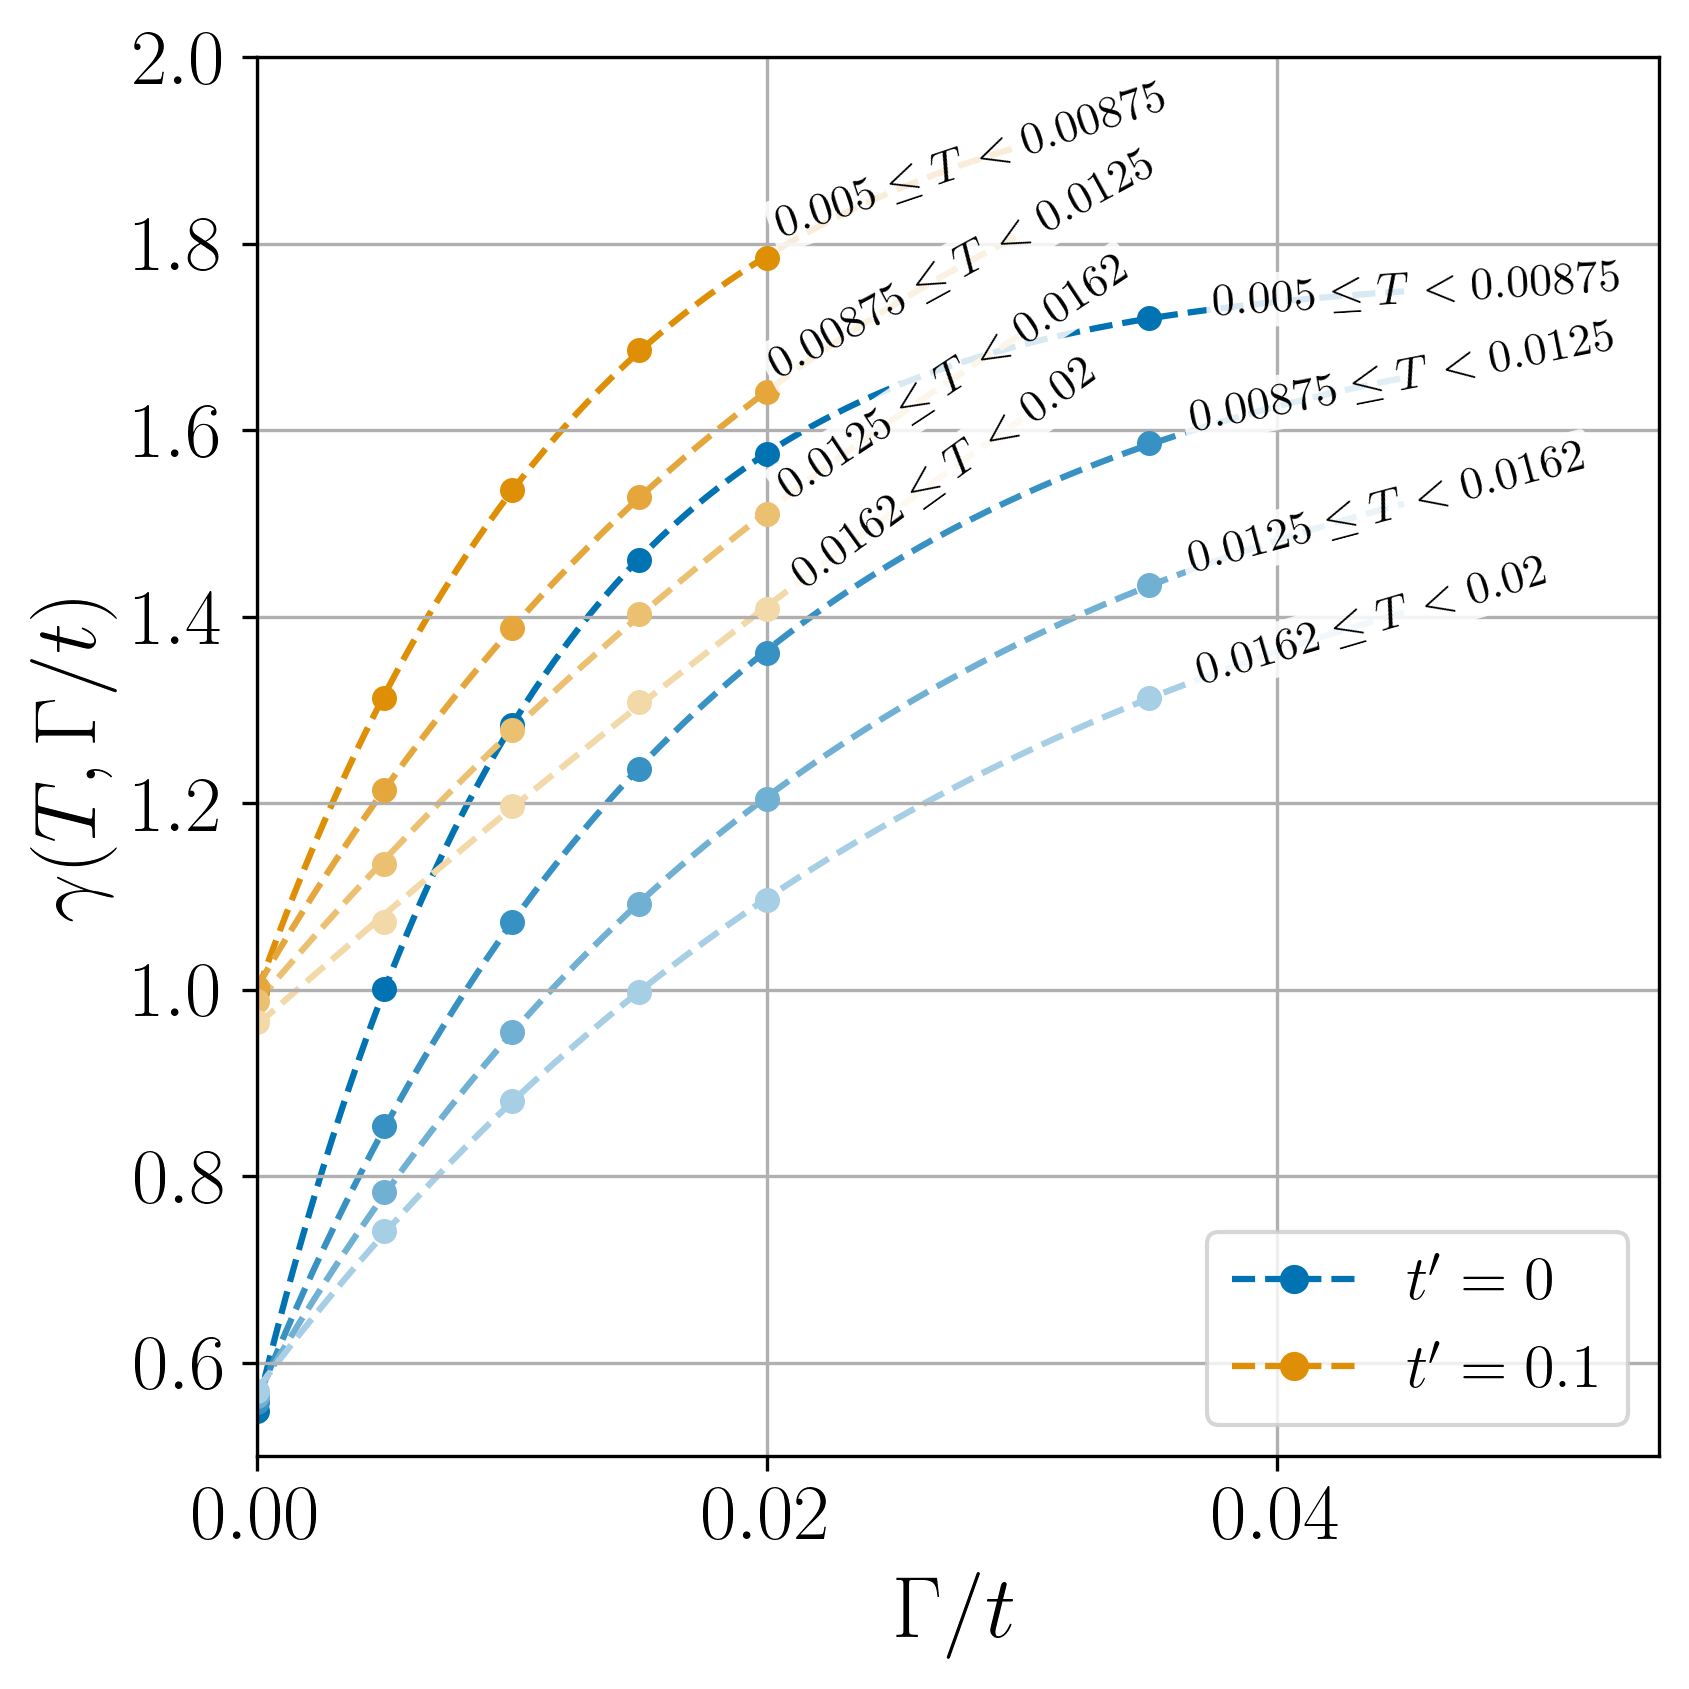

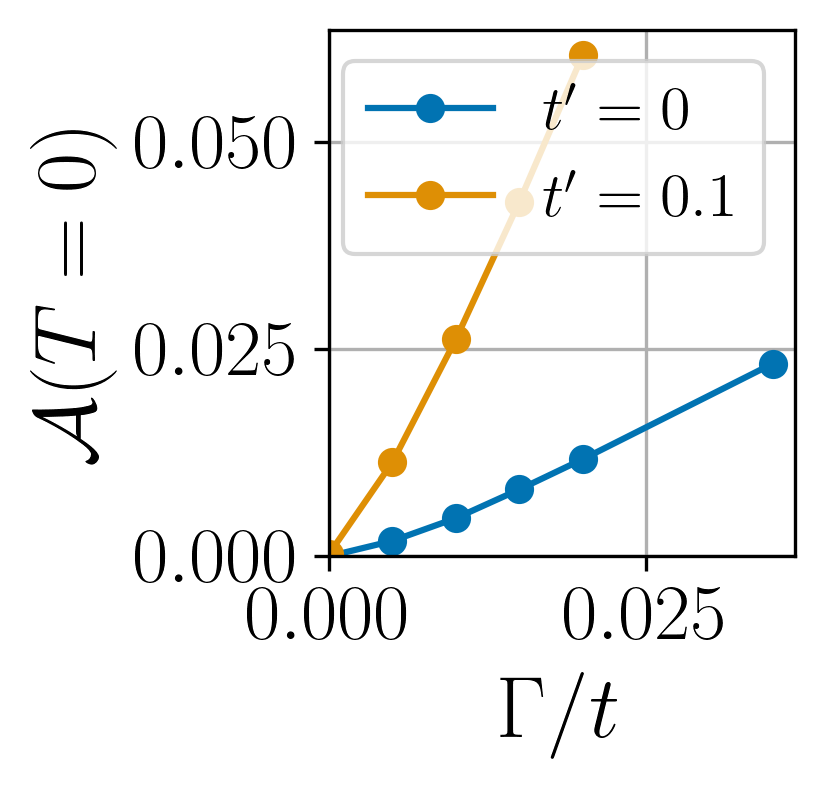

/tmp/ipykernel_453563/2851939553.py:301: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


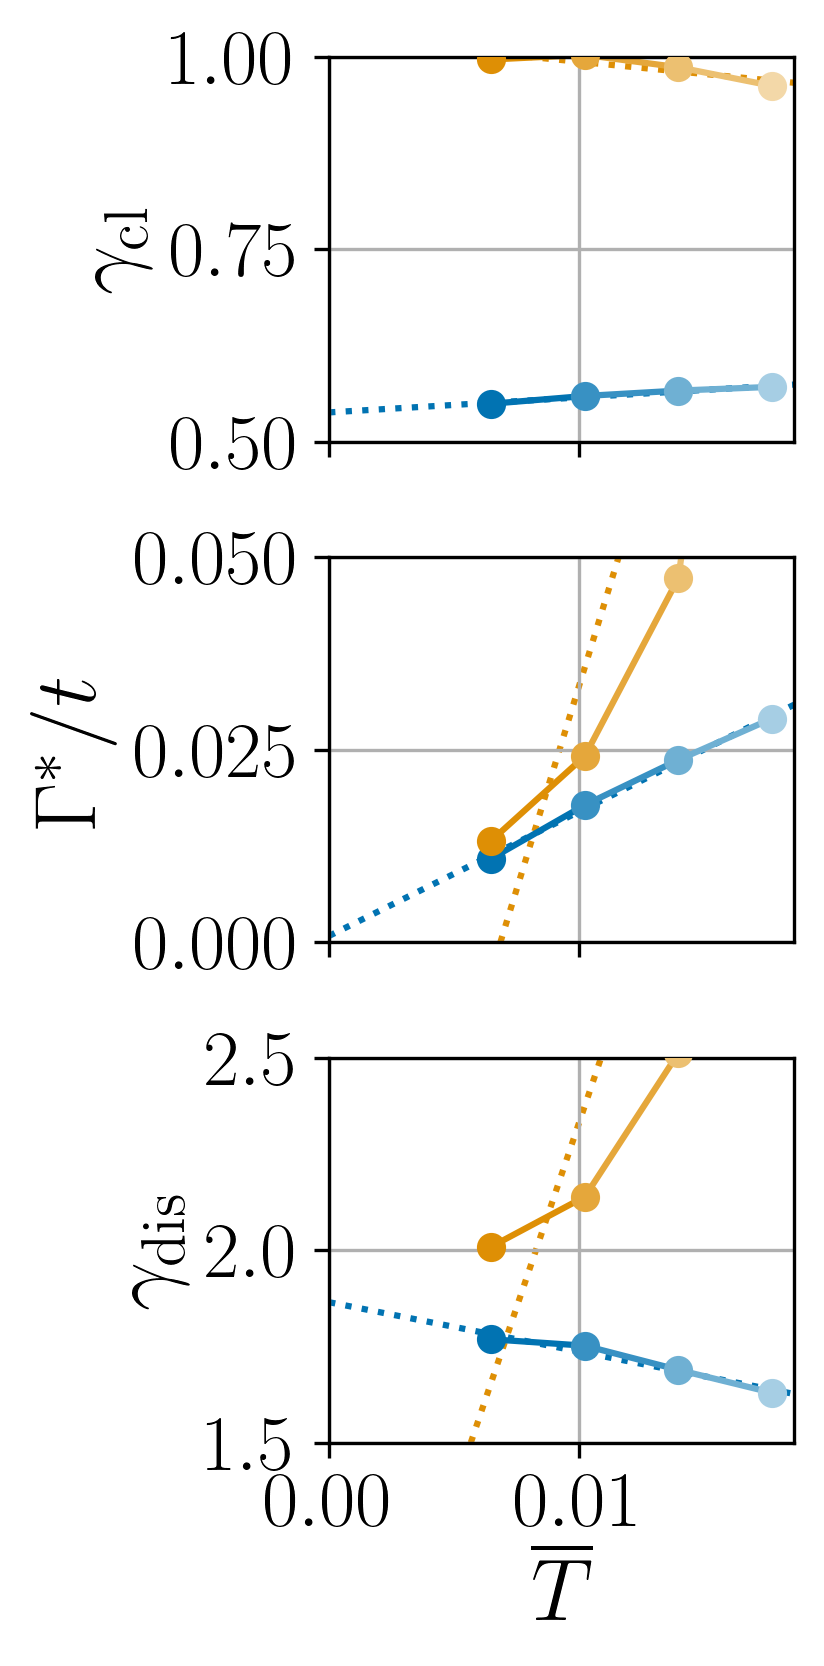

In [6]:
update_mpl_params(bigger_labels=3)

U = 3
N_scales = 4
fit_c = True


def exp_func(x, g_clean, Gstar, g_dis):
    return (g_clean - g_dis) * np.exp(-x / Gstar) + g_dis


def get_shade(base_color, factor):
    """Blends base_color with white: factor=1.0 (dark/base), factor~0.35 (clear/light)."""
    rgb = np.array(mcolors.to_rgb(base_color))
    return rgb * factor + (1.0 - factor) * np.array([1.0, 1.0, 1.0])


# List of tp configurations: i-th element uses color_list[i]
tp_configs = [
    (0.0, np.array([0.0, 0.005, 0.01, 0.015, 0.02, 0.035])),
    (0.1, np.array([0.0, 0.005, 0.01, 0.015, 0.02])),
    #(0.2, np.array([0.0, 0.005, 0.01, 0.02])),
]

func = exp_func if fit_c else lambda x, a, b: exp_func(x, a, b, 2)
p0 = [0.5, 0.5, 2] if fit_c else [0.5, 0.5]
bounds = (
    ([0, 0, 0], [np.inf, np.inf, np.inf]) if fit_c else ([0, 0], [np.inf, np.inf])
)

results = []

# --- Data Processing Loop ---
for i, (tp, G_list) in enumerate(tp_configs):
    base_color = color_list[i]
    p_inv_scales = [[] for _ in range(N_scales)]
    p_OZ = []
    n_c_list = []

    for G in G_list:
        filename = (
            f"data/scaling/tp{tp:.5g}U{U:.5g}.h5"
            if G == 0
            else f"data/scaling/G{G:.5g}tp{tp:.5g}U{U:.5g}.h5"
        )

        with HDFArchive(filename, "r") as ar:
            T = np.array(ar["T"])
            n = np.array(ar["n"])
            invchi = np.array(ar["invchi_min"])
            OZ_weight = np.array(ar["OZ_weight"])

        c_list = []
        gamma_list = []

        for j in range(len(n)):
            par, _ = curve_fit(
                HMM, T, invchi[j, :], p0=[1, 0.5, 0.0], maxfev=10000
            )
            gamma_list.append(par[1])
            c_list.append(par[2])

        slope, intercept = np.polyfit(n, c_list, 1)
        n_c_list.append(-intercept / slope)

        idx = np.argsort(n)
        n_sorted = n[idx]
        n_c = n_c_list[-1]

        invchi_nc = np.array(
            [np.interp(n_c, n_sorted, invchi[idx, k]) for k in range(len(T))]
        )
        OZ_nc = np.array(
            [np.interp(n_c, n_sorted, OZ_weight[idx, k]) for k in range(len(T))]
        )

        scale_slices = np.array_split(np.arange(len(T)), N_scales)

        for s, sl in enumerate(scale_slices):
            par, _ = curve_fit(
                HMM, T[sl], invchi_nc[sl], p0=[1, 0.5, 0.0], maxfev=10000
            )
            p_inv_scales[s].append(par)

        par, _ = curve_fit(HMM, T[:6], OZ_nc[:6], p0=[6, 1.5, 0.01], maxfev=10000)
        p_OZ.append(par)

    p_inv_scales = np.array(p_inv_scales)
    p_OZ = np.array(p_OZ)

    gamma_scales = p_inv_scales[:, :, 1]
    alpha = p_OZ[:, 1]
    A0 = p_OZ[:, 2]

    G_fit = np.linspace(G_list.min(), G_list.max() + 1e-2, 200)

    par_gamma_scales = np.array(
        [
            curve_fit(
                func, G_list, gamma_scales[s], p0=p0, bounds=bounds, maxfev=10000
            )[0]
            for s in range(N_scales)
        ]
    )

    T_star = np.array([T[sl][len(sl) // 2] for sl in scale_slices])

    results.append(
        {
            "tp_idx": i,
            "tp": tp,
            "base_color": base_color,
            "G_list": G_list,
            "G_fit": G_fit,
            "T": T,
            "scale_slices": scale_slices,
            "gamma_scales": gamma_scales,
            "par_gamma_scales": par_gamma_scales,
            "alpha": alpha,
            "A0": A0,
            "T_star": T_star,
            "x_frac": [1.3, 1.4, 1.5],
        }
    )

# --- Figure 1: Exponential Fits ---
fig, ax = plt.subplots(figsize=(6, 6))
fig.set_dpi(300)

# Step 1: Plot all data points and fitted curves
for res in results:
    base_color = res["base_color"]
    G_list = res["G_list"]
    G_fit = res["G_fit"]
    scale_slices = res["scale_slices"]
    gamma_scales = res["gamma_scales"]
    par_gamma_scales = res["par_gamma_scales"]

    for s, sl in enumerate(scale_slices):
        # Reversed scale factor: s=0 is dark (1.0), s=max is light (0.35)
        factor = 1.0 - 0.65 * (s / max(1, N_scales - 1))
        color = get_shade(base_color, factor)

        ax.plot(G_list, gamma_scales[s], "o", color=color, markersize=5)
        ax.plot(
            G_fit,
            func(G_fit, *par_gamma_scales[s]),
            "--",
            color=color,
            zorder=-1,
        )

ax.set_xlabel(r"$\Gamma/t$")
ax.set_ylabel(r"$\gamma(T, \Gamma/t)$")
ax.set_ylim(0.5, 2)
ax.set_xlim(0, 0.055)
ax.grid(True)

# Step 2: Force canvas draw so pixel coordinate transformations are accurate
fig.canvas.draw()

# Step 3: Add black text labels positioned towards the end and aligned with local tangent
for i, res in enumerate(results):
    G_list = res["G_list"]
    T = res["T"]
    scale_slices = res["scale_slices"]
    par_gamma_scales = res["par_gamma_scales"]

    G_min, G_max = G_list.min(), G_list.max()
    G_range = G_max - G_min

    for s, sl in enumerate(scale_slices):
        T_start = T[sl][0]
        T_end = T[sl][-1] + (T[sl][1] - T[sl][0]) if len(sl) > 1 else T[sl][0]
        label_text = rf"${T_start:.3g} \leq T < {T_end:.3g}$"

        # Position labels towards the end of the curves
        x_frac = res["x_frac"][i] - 0.05 * (s / max(1, N_scales - 1))
        x_center = G_min + x_frac * G_range
        y_center = func(x_center, *par_gamma_scales[s])

        # Compute tangent angle in display space centered at (x_center, y_center)
        dx = G_range * 1e-4
        p_left = ax.transData.transform(
            (x_center - dx, func(x_center - dx, *par_gamma_scales[s]))
        )
        p_right = ax.transData.transform(
            (x_center + dx, func(x_center + dx, *par_gamma_scales[s]))
        )
        angle = np.degrees(
            np.arctan2(p_right[1] - p_left[1], p_right[0] - p_left[0])
        )

        ax.text(
            x_center,
            y_center,
            label_text,
            color="black",
            fontsize=11,
            ha="center",
            va="center",
            rotation=angle,
            rotation_mode="anchor",
            bbox=dict(
                boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85
            ),
        )

# Legend entries for tp
for res in results:
    ax.plot(
        [],
        [],
        "o--",
        color=res["base_color"],
        label=rf"$t' = {res['tp']:.3g}$",
    )

ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# --- Figure 2: OZ Curves ---
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
fig.set_dpi(300)

for res in results:
    tp = res["tp"]
    base_color = res["base_color"]
    G_list = res["G_list"]

    ax.plot(G_list, res["A0"], "o-", color=base_color, label=rf"$t' = {tp:.3g}$")

ax.set_ylabel(r"$\mathcal{A}(T=0)$")
ax.set_xlabel(r"$\Gamma/t$")
ax.grid(True)
ax.legend()

ax.set_ylim(bottom=0)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

# --- Figure 3: Fitted Parameters vs T* ---
labels = [
    r"$\gamma_{\mathrm{cl}}$",
    r"$\Gamma^*/t$",
    r"$\gamma_{\mathrm{dis}}$",
]
fig, ax = plt.subplots(3, 1, figsize=(2, 6), sharex=True, gridspec_kw={'hspace': 0.3})
fig.set_dpi(300)

for res in results:
    tp = res["tp"]
    base_color = res["base_color"]
    T_star = res["T_star"]
    params = res["par_gamma_scales"].T

    for i_p in range(3):
        # Linear fit line in the background
        m, q = np.polyfit(T_star, params[i_p], 1)
        ax[i_p].axline((0, q), slope=m, linestyle=":", color=base_color, zorder=1)

        # Plot individual points and connecting segments with reversed T-dependent shading
        for s in range(len(T_star)):
            # Reversed scale factor: s=0 is dark (1.0), s=max is light (0.35)
            factor = 1.0 - 0.65 * (s / max(1, N_scales - 1))
            color = get_shade(base_color, factor)

            # Connecting line segment to next temperature scale point
            if s < len(T_star) - 1:
                ax[i_p].plot(
                    T_star[s : s + 2],
                    params[i_p][s : s + 2],
                    "-",
                    color=color,
                    zorder=2,
                )

            # Point marker
            ax[i_p].plot(
                T_star[s],
                params[i_p][s],
                "o",
                color=color,
                zorder=3,
            )

for i_p in range(3):
    ax[i_p].set_ylabel(labels[i_p])
    ax[i_p].grid(True)

ax[0].set_ylim(0.5, 1)
ax[1].set_ylim(0.0, 0.05)
ax[2].set_ylim(1.5, 2.5)
ax[2].set_xlabel(r"$\overline{T}$")

for a in ax:
    a.set_xlim(left=0)

plt.tight_layout()
plt.show()

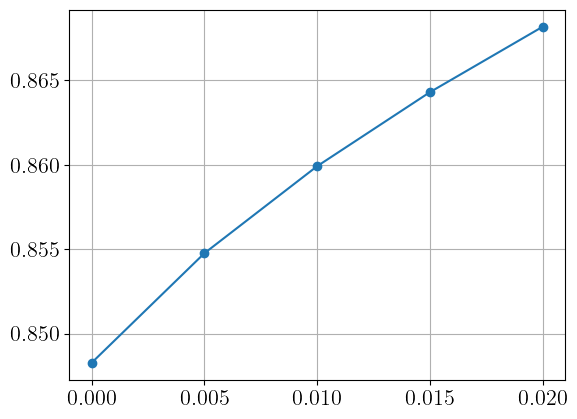

In [38]:
plt.plot(G_list, n_c_list, 'o-')
plt.grid()

/home/carlo/Desktop/qc/scripts/plot.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


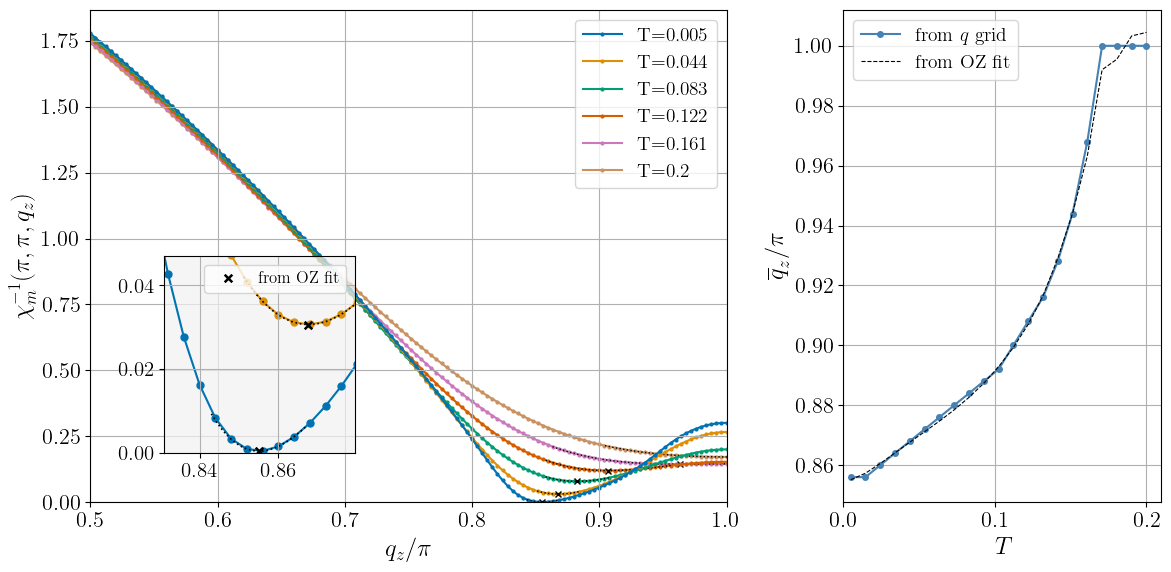

In [3]:
n = 0.88583
U = 3

with HDFArchive(f"data/chimin/G0.05tp0.1n{n:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_chimin(data)
plt.show()

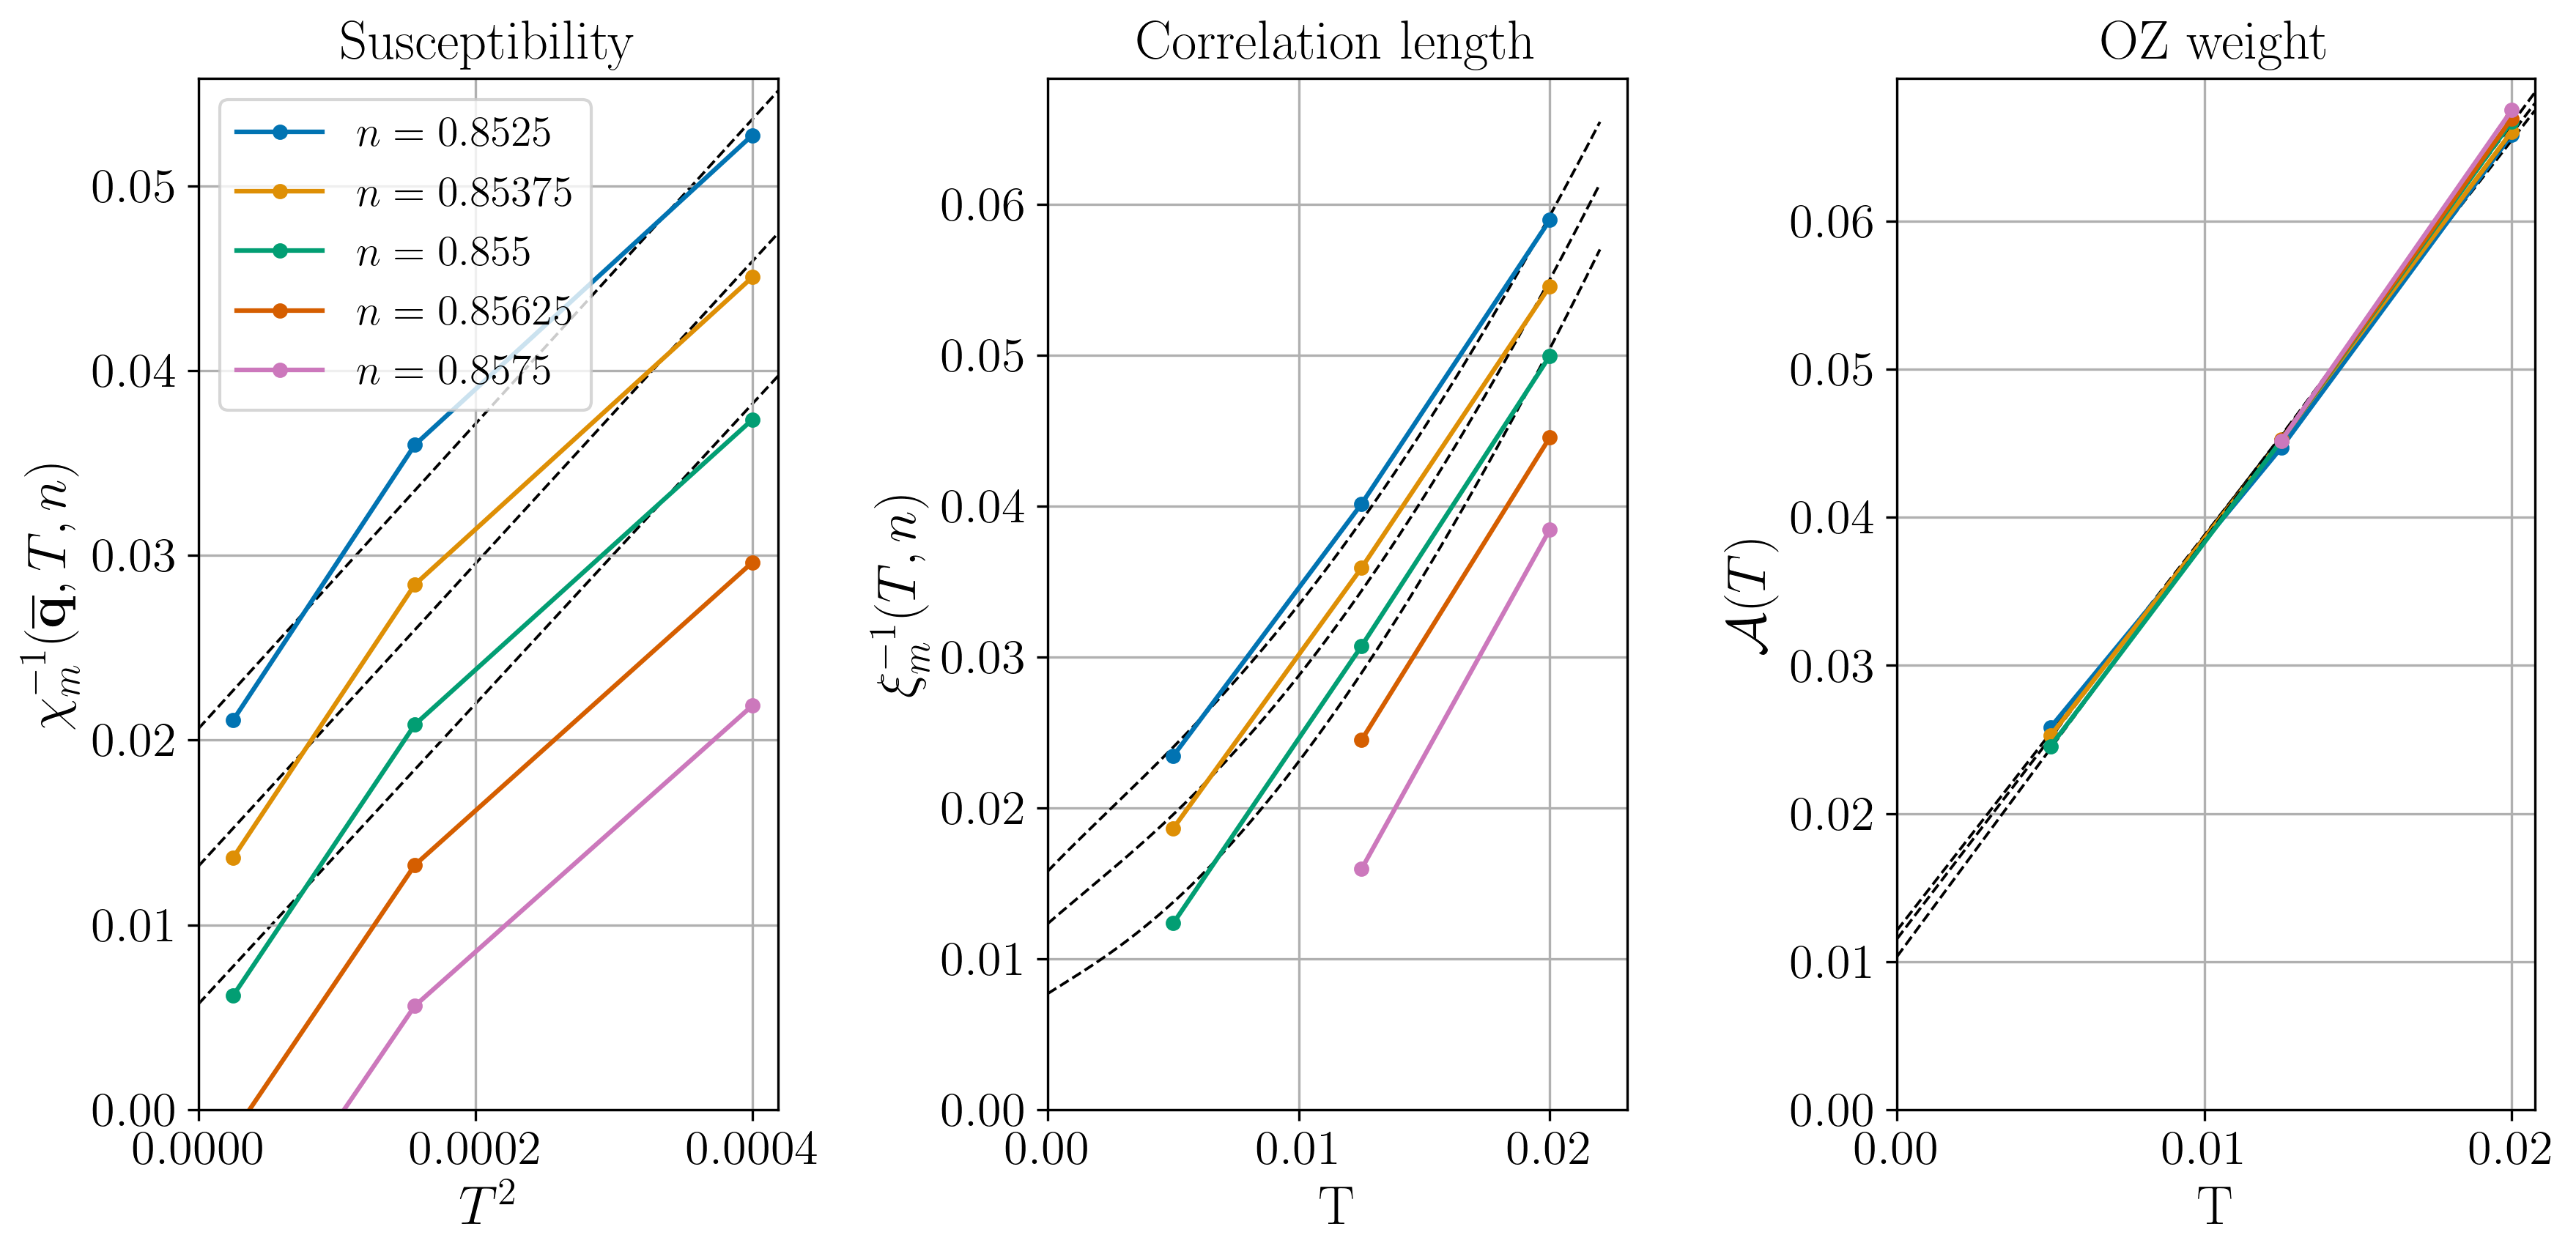

In [5]:
U = 3
Gamma = 0.005
tp = 0.1

data = {}
with HDFArchive(f"data/scaling/G{Gamma:.5g}tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(2, 1, 1), fit=True, right='OZ')
plt.show()

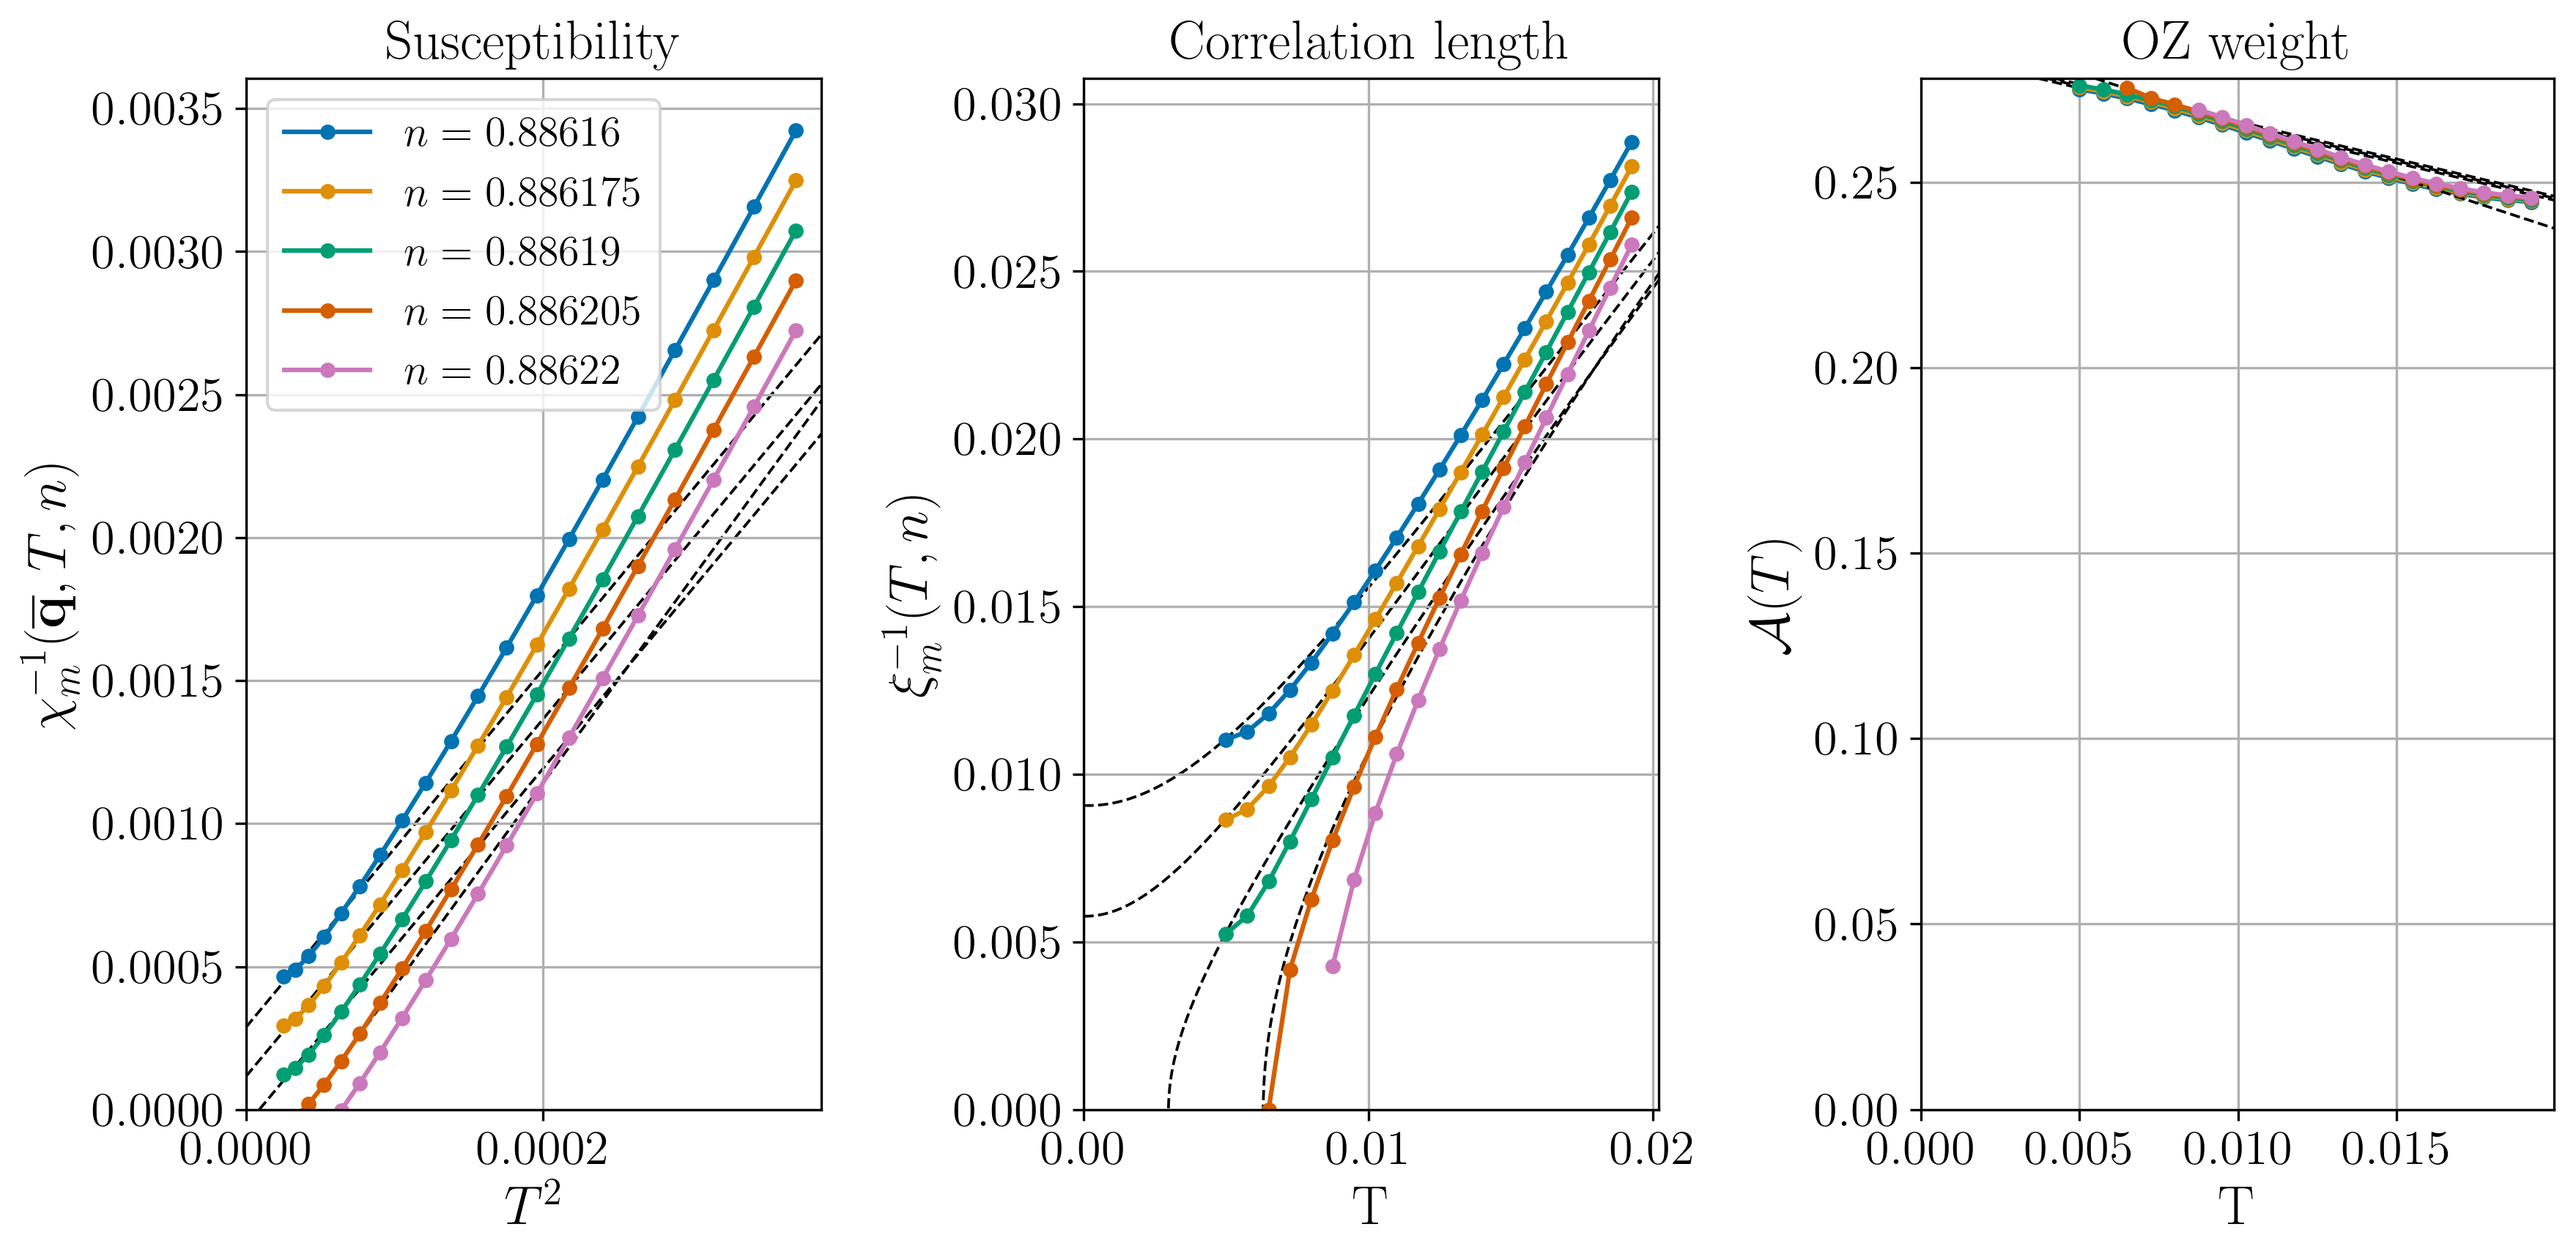

In [13]:
U = 3
Gamma = 0.005
tp = 0.2

data = {}
with HDFArchive(f"data/scaling/G{Gamma:.5g}tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(2, 1, 1), fit=True, right='OZ')
plt.show()

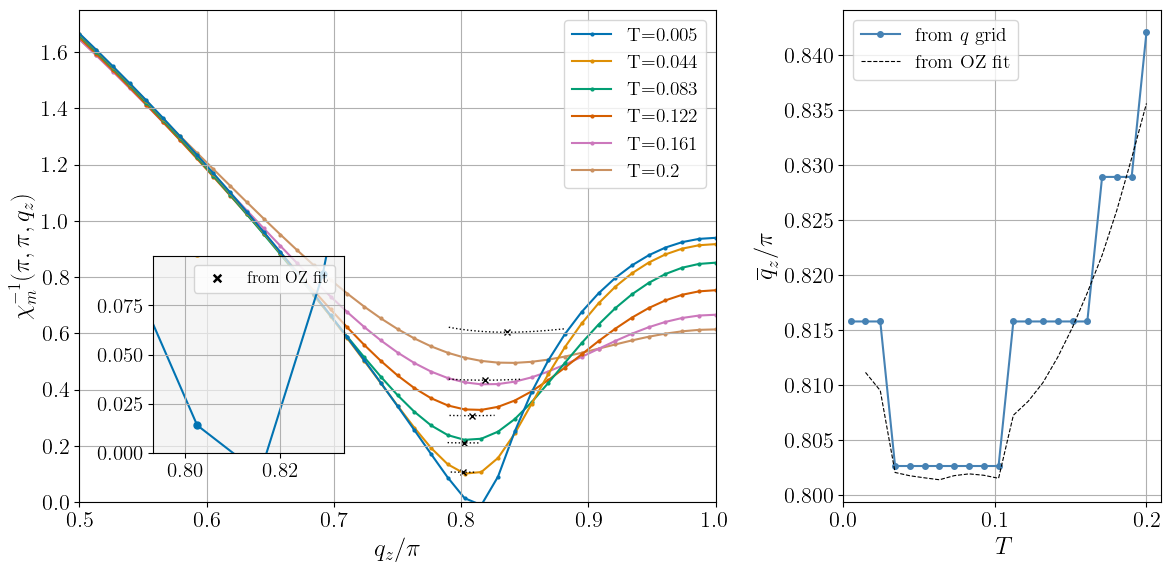

In [14]:
n = 0.84
U = 3
v = 0.3

with HDFArchive(f"data/chimin/v{v:.5g}tp0n{n:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_chimin(data)
plt.show()

In [13]:
U = 3
v = 0.1
tp = 0.1

data = {}
with HDFArchive(f"data/scaling/v{v:.5g}tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(2, 1, 1.5), fit=True, right='OZ')
plt.show()

HDF5-DIAG: Error detected in HDF5 (2.1.0) MPI-process 0:
  #000: /home/conda/feedstock_root/build_artifacts/hdf5_1775243212486/work/src/H5Odeprec.c line 508 in H5Oget_info_by_name1(): can't get deprecated info for object
    major: Object header
    minor: Can't get value
  #001: /home/conda/feedstock_root/build_artifacts/hdf5_1775243212486/work/src/H5Odeprec.c line 254 in H5O__get_info_old(): can't get data model info for object
    major: Object header
    minor: Can't get value
  #002: /home/conda/feedstock_root/build_artifacts/hdf5_1775243212486/work/src/H5VLcallback.c line 6088 in H5VL_object_get(): get failed
    major: Virtual Object Layer
    minor: Can't get value
  #003: /home/conda/feedstock_root/build_artifacts/hdf5_1775243212486/work/src/H5VLcallback.c line 6056 in H5VL__object_get(): get failed
    major: Virtual Object Layer
    minor: Can't get value
  #004: /home/conda/feedstock_root/build_artifacts/hdf5_1775243212486/work/src/H5VLnative_object.c line 269 in H5VL__nati

RuntimeError: .. Error occurred at Wed Sep  9 14:28:39 2026

.. Error .. calling C++ overload 
.. get_all_subgroup_dataset_names() -> std::vector<std::string> 
.. in implementation of method Group.keys
.. C++ error was : 
Error in h5::get_group_elements_name_ds_grp: H5Oget_info_by_name call failed

In [3]:
# --- Configuration & Setup ---
v_list = np.array([0., 0.1, 0.15, 0.2, 0.25])  # Iterate over disorder strength v instead of G
U = 3
tp = 0.
N_scales = 5
fit_c = True

def exp_func(x, g_clean, Gstar, g_dis):
    return (g_clean - g_dis) * np.exp(-x / Gstar) + g_dis

p_inv_scales = [[] for _ in range(N_scales)]
p_OZ = []
n_c_list = []
G_list = []  # Will store the extrapolated Gamma values for each v

# --- Data Extraction and Gamma Extrapolation Loop ---
for v in v_list:
    filename = (f"data/scaling/G0tp{tp:.5g}U{U:.5g}.h5" if v == 0
                else f"data/scaling/v{v:.5g}tp{tp:.5g}U{U:.5g}.h5")

    with HDFArchive(filename, "r") as ar:
        T = np.array(ar['T'])
        n = np.array(ar['n'])
        invchi = np.array(ar['invchi_min'])
        OZ_weight = np.array(ar['OZ_weight'])
                
        # Read self-energy arrays to extrapolate Gamma
        Siw = np.array(ar['S_list'])      # Self-energy \Sigma(i\omega)

    # 1. Extrapolate Gamma from -Im[Sigma(iw)] as iw -> 0 (averaged over T and n)
    # Using low-frequency points for polynomial fit
    n_pts = 4
    niw_low = np.arange(n_pts)

    if v != 0:
        im_sig_low = -np.imag(Siw[:,:,:n_pts]).mean(axis=(0, 1))
            
        poly_fit = np.polyfit(niw_low, im_sig_low, deg=2)
        G = np.polyval(poly_fit, 0.0)
    else:
        G = 0
    
    # Ensure Gamma is non-negative
    G_list.append(max(0.0, G))

    # 2. Critical density & scaling analysis
    c_list = []
    gamma_list = []

    for i in range(len(n)):
        par, _ = curve_fit(HMM, T, invchi[i, :],
                           p0=[1, 0.5, 0.], maxfev=10000)
        gamma_list.append(par[1])
        c_list.append(par[2])

    slope, intercept = np.polyfit(n, c_list, 1)
    n_c_list.append(-intercept / slope)

    idx = np.argsort(n)
    n_sorted = n[idx]
    n_c = n_c_list[-1]

    invchi_nc = np.array([
        np.interp(n_c, n_sorted, invchi[idx, j])
        for j in range(len(T))
    ])
    OZ_nc = np.array([
        np.interp(n_c, n_sorted, OZ_weight[idx, j])
        for j in range(len(T))
    ])

    scale_slices = np.array_split(np.arange(len(T)), N_scales)

    for s, sl in enumerate(scale_slices):
        par, _ = curve_fit(HMM, T[sl], invchi_nc[sl], p0=[1, 0.5, 0.], maxfev=10000)
        p_inv_scales[s].append(par)

    par, _ = curve_fit(HMM, T, OZ_nc, p0=[6, 1.5, 0.01], maxfev=10000)
    p_OZ.append(par)

# Convert computed lists to numpy arrays
G_list = np.array(G_list)
p_inv_scales = np.array(p_inv_scales)
p_OZ = np.array(p_OZ)

gamma_scales = p_inv_scales[:, :, 1]
alpha = p_OZ[:, 1]
A0 = p_OZ[:, 2]

# --- Exponential Fits against computed G_list ---
G_fit = np.linspace(G_list.min(), G_list.max() + 1e-2, 200)

func = exp_func if fit_c else lambda x, a, b: exp_func(x, a, b, 2)
p0 = [0.5, 0.5, 2] if fit_c else [0.5, 0.5]
bounds = ([0, 0, 0], [np.inf, np.inf, np.inf]) if fit_c else ([0, 0], [np.inf, np.inf])

par_gamma_scales = np.array([
    curve_fit(func, G_list, gamma_scales[s],
              p0=p0, bounds=bounds, maxfev=10000)[0]
    for s in range(N_scales)
])

# --- Plot 1: Exponential fits vs Gamma ---
plt.figure(figsize=(7, 6))

for s, sl in enumerate(scale_slices):
    plt.plot(G_list, gamma_scales[s], 's',
             color=color_list[s + 1],
             label=rf'${T[sl][0]:.4g} \leq T \leq {T[sl][-1]:.4g}$')
    plt.plot(G_fit, func(G_fit, *par_gamma_scales[s]), '--',
             color=color_list[s + 1])

plt.plot(G_fit, func(G_fit, 0.5, 1e-8, 2), ':', color='red')
plt.xlabel(r'$\Gamma$')
plt.ylabel(r'$\gamma$')
plt.xlim(0, G_list.max() + 2e-3)
plt.ylim(0.5, 2.01)
plt.legend(loc='lower right')
plt.grid()
plt.tight_layout()
plt.show()

# --- Plot 2: OZ curves vs Gamma ---
fig, ax = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

ax[0].plot(G_list, A0, 's-')
ax[1].plot(G_list, alpha, 's-')

par = np.polyfit(G_list, alpha, deg=1)
ax[1].axline((0, par[1]), slope=par[0], linestyle=':', color='black', zorder=-1)

for a in ax:
    a.set_ylabel(r'$A_0$')
    a.set_xlim(0, G_list.max() + 2e-3)
    a.grid()

ax[1].set_xlabel(r'$\Gamma$')
ax[1].legend(loc='lower right')
ax[0].set_ylim(bottom=0)
    
plt.tight_layout()
plt.show()

# --- Plot 3: Fitted parameters vs T* ---
T_star = np.array([T[sl][len(sl) // 2] for sl in scale_slices])
T_fit = np.linspace(0, T_star.max(), 100)

params = par_gamma_scales.T
labels = [r'$\gamma_{\mathrm{clean}}$', r'$\Gamma^*$', r'$\gamma_{\mathrm{dis}}$']

fig, ax = plt.subplots(3, 1, figsize=(7, 6), sharex=True)

for i in range(3):
    ax[i].plot(T_star, params[i], 's-')
    
    # Linear extrapolation
    m, q = np.polyfit(T_star, params[i], 1)
    ax[i].axline((0, q), slope=m, linestyle=':', color='black')
    
    ax[i].set_ylabel(labels[i])
    ax[i].grid()

ax[1].set_ylim(bottom=0)
ax[2].set_xlabel(r'$T^*$')

for a in ax:
    a.set_xlim(left=0)

plt.tight_layout()
plt.show()

Cannot open the HDF file data/scaling/v0.1tp0U3.h5


HDF5-DIAG: Error detected in HDF5 (2.1.0) MPI-process 0:
  #000: /home/conda/feedstock_root/build_artifacts/hdf5_1775243212486/work/src/H5F.c line 821 in H5Fopen(): unable to synchronously open file
    major: File accessibility
    minor: Unable to open file
  #001: /home/conda/feedstock_root/build_artifacts/hdf5_1775243212486/work/src/H5F.c line 782 in H5F__open_api_common(): unable to open file
    major: File accessibility
    minor: Unable to open file
  #002: /home/conda/feedstock_root/build_artifacts/hdf5_1775243212486/work/src/H5VLcallback.c line 3869 in H5VL_file_open(): open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: /home/conda/feedstock_root/build_artifacts/hdf5_1775243212486/work/src/H5VLcallback.c line 3718 in H5VL__file_open(): open failed
    major: Virtual Object Layer
    minor: Can't open object
  #004: /home/conda/feedstock_root/build_artifacts/hdf5_1775243212486/work/src/H5VLnative_file.c line 128 in H5VL__native_file_open(): unable

RuntimeError: .. Error occurred at Wed Sep  9 23:39:06 2026

.. Error .. in calling C++ overload of constructor :
.. (no C++ name)(std::string name, char mode) -> 
.. C++ error was : 
Opening/Creating the file data/scaling/v0.1tp0U3.h5 failed

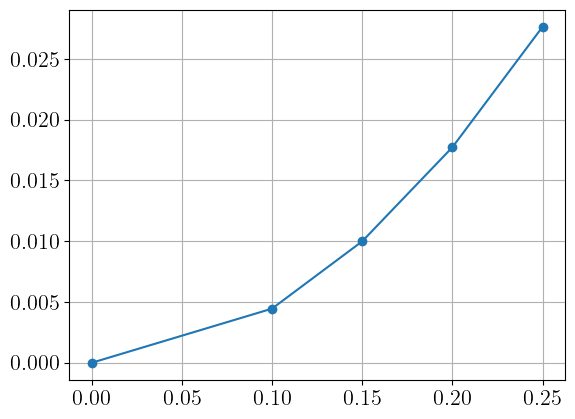

In [35]:
plt.plot(v_list, G_list, 'o-')
plt.grid()

In [19]:
U = 3
v = 0.25
tp = 0.

data = {}
with HDFArchive(f"data/scaling/v{v:.5g}tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(2, 1, 1.5), fit=True, right='OZ')
plt.show()

HDF5-DIAG: Error detected in HDF5 (2.1.0) MPI-process 0:
  #000: /home/conda/feedstock_root/build_artifacts/hdf5_1775243212486/work/src/H5Odeprec.c line 508 in H5Oget_info_by_name1(): can't get deprecated info for object
    major: Object header
    minor: Can't get value
  #001: /home/conda/feedstock_root/build_artifacts/hdf5_1775243212486/work/src/H5Odeprec.c line 254 in H5O__get_info_old(): can't get data model info for object
    major: Object header
    minor: Can't get value
  #002: /home/conda/feedstock_root/build_artifacts/hdf5_1775243212486/work/src/H5VLcallback.c line 6088 in H5VL_object_get(): get failed
    major: Virtual Object Layer
    minor: Can't get value
  #003: /home/conda/feedstock_root/build_artifacts/hdf5_1775243212486/work/src/H5VLcallback.c line 6056 in H5VL__object_get(): get failed
    major: Virtual Object Layer
    minor: Can't get value
  #004: /home/conda/feedstock_root/build_artifacts/hdf5_1775243212486/work/src/H5VLnative_object.c line 269 in H5VL__nati

RuntimeError: .. Error occurred at Mon Sep  7 20:34:22 2026

.. Error .. calling C++ overload 
.. get_all_subgroup_dataset_names() -> std::vector<std::string> 
.. in implementation of method Group.keys
.. C++ error was : 
Error in h5::get_group_elements_name_ds_grp: H5Oget_info_by_name call failed

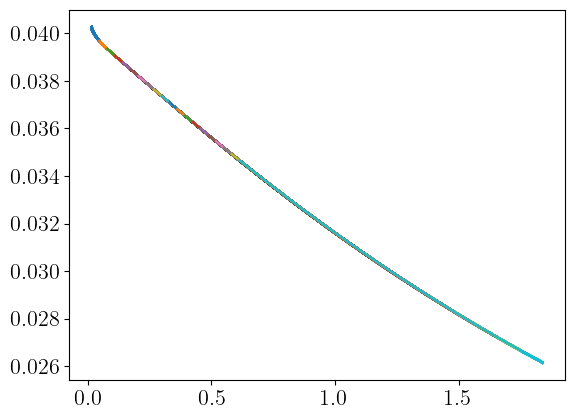

In [12]:
w_n = np.array([(2*np.arange(np.shape(data['S_list'])[-1]) + 1) * np.pi * T for T in data['T']])
for i_n in range(len(data['n'])):
    par = np.array([np.polyfit(w_n[iT,:4], data['S_list'][i_n,iT,:4].imag, deg=3) for iT in range(len(data['T']))])
    for iT in range(len(data['T'])):
        plt.plot(w_n[:,:20], -data['S_list'][i_n,:,:20].imag)

plt.show()

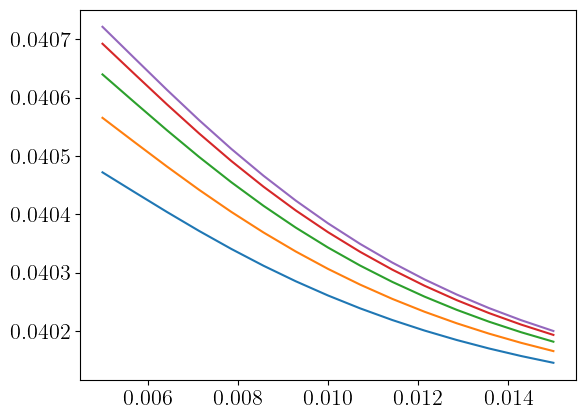

In [13]:
w_n = np.array([(2*np.arange(np.shape(data['S_list'])[-1]) + 1) * np.pi * T for T in data['T']])
for i_n in range(len(data['n'])):
    par = np.array([np.polyfit(w_n[iT,:4], -data['S_list'][i_n,iT,:4].imag, deg=3) for iT in range(len(data['T']))])
    plt.plot(data['T'], par[:,-1])

plt.show()

(15, 2048)


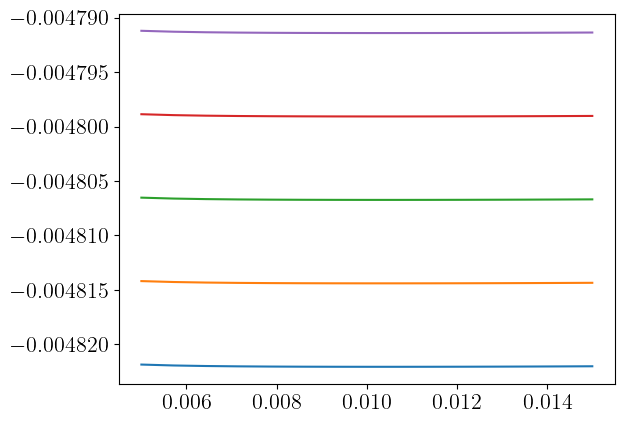

In [21]:
w_n = np.array([(2*np.arange(np.shape(data['S_list'])[-1]) + 1) * np.pi * T for T in data['T']])
print(np.shape(w_n))
for i_n in range(len(data['n'])):
    par = np.array([np.polyfit(w_n[iT,:4], data['S_list'][i_n,iT,:4].real, deg=3) for iT in range(len(data['T']))])
    plt.plot(data['T'], par[:,-1])

plt.show()

<unknown>:44: SyntaxWarning: invalid escape sequence '\p'
<unknown>:44: SyntaxWarning: invalid escape sequence '\p'
/home/carlo/Desktop/qc/scripts/plot.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  if isinstance(data['bz_fine'], dict):
/tmp/ipykernel_342215/1090516144.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


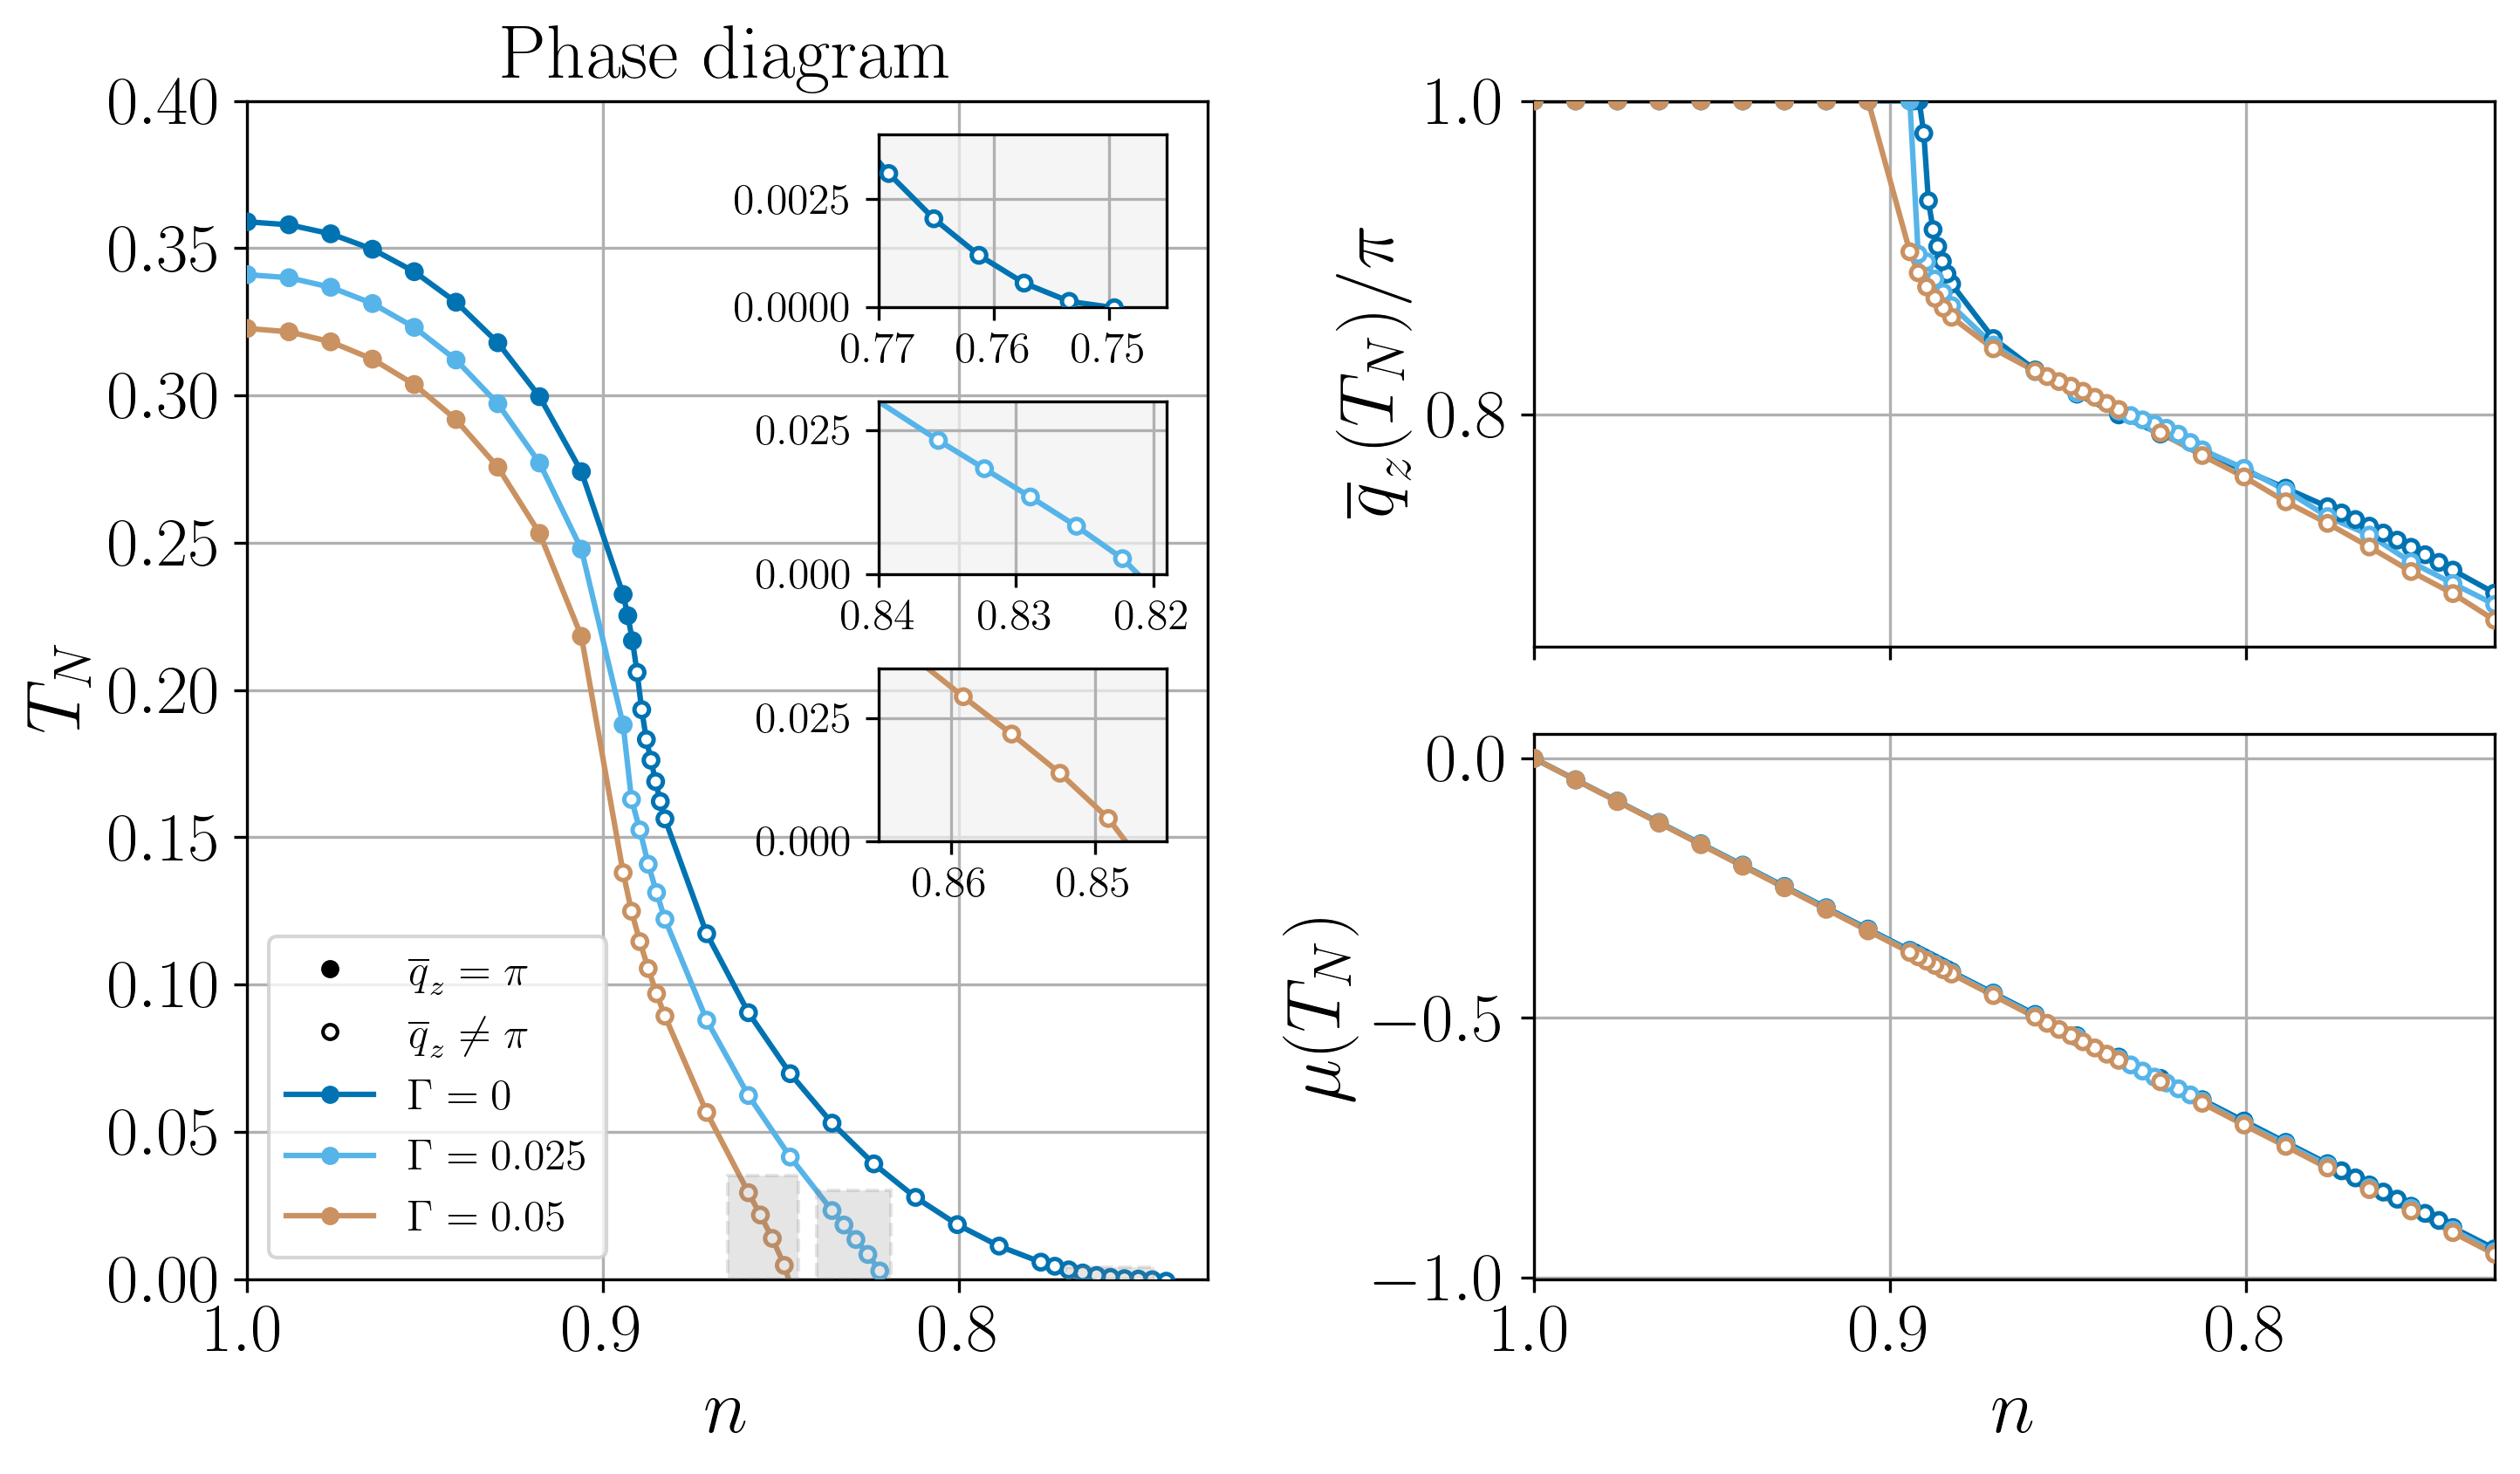

In [4]:
U = 3
tp = 0.
G_list = [0., 0.025, 0.05]

data_list = []
for G in G_list:

    with HDFArchive(f"data/diagram/{rf'G{G:.5g}tp{tp:.5g}U{U:.5g}.h5'}", "r") as ar:
        data_list.append({k: ar[k] for k in ar})

fig1 = plot_diagram(data_list, G_list, r"\Gamma", figsize=(10, 6), 
                    inset_xrange=[(0.745, 0.77), (0.819, 0.84), (0.845, 0.865)], inset_yrange=[(0, 0.004), (0, 0.03), (0, 0.035)], bigger_labels=3)

plt.tight_layout()
plt.show()

<unknown>:43: SyntaxWarning: invalid escape sequence '\p'
<unknown>:43: SyntaxWarning: invalid escape sequence '\p'
/home/carlo/Desktop/qc/scripts/plot.py:43: SyntaxWarning: invalid escape sequence '\p'
  ax[0].set_xlabel('$q_z/\pi$')


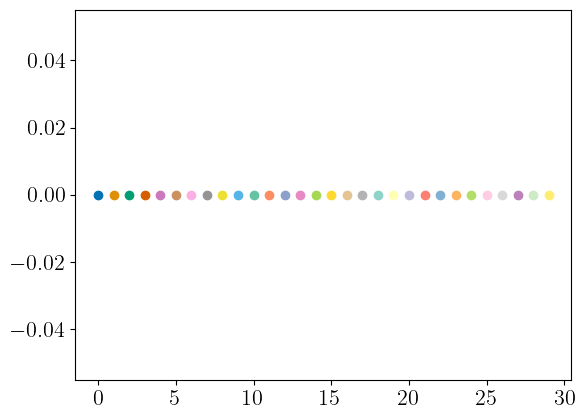

In [24]:
color_list = sns.color_palette('colorblind') + sns.color_palette("Set2") + sns.color_palette("Set3")

for i in range(30):
    plt.scatter(i, 0, color=color_list[i])